In [1]:
import os, sys
import warnings
import time

import pandas as pd
import numpy as np
import math

import pickle

from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.graph_objects as go
from matplotlib.lines import Line2D
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

import lifelines
from lifelines.utils import concordance_index
from lifelines.statistics import logrank_test
from sksurv.util import Surv
from sksurv.metrics import concordance_index_ipcw

import tensorflow as tf
import tensorflow_probability as tfp

config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config = config)

from tensorflow import keras
from tensorflow.keras import optimizers, initializers, regularizers, layers

import scipy.stats as stats
from scipy.stats import norm, t, probplot, pearsonr, spearmanr, rankdata
from scipy.stats import truncnorm as truncnorm_scipy
from scipy.stats import gamma as gamma_dist
from scipy.special import gamma

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold

import thetaflow as thf
print("Thetaflow version: {}".format(thf.__version__))

import json
import gc
import glob
from pathlib import Path

sys.path.append("../")
import gndr_utils as utils
import utils_ph as ph
import bct

I0000 00:00:1782957200.076331  226807 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782957200.543360  226807 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782957202.078045  226807 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Thetaflow version: 0.0.34


I0000 00:00:1782957203.822624  226807 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 17768 MB memory:  -> device: 0, name: NVIDIA RTX A4500, pci bus id: 0000:01:00.0, compute capability: 8.6
I0000 00:00:1782957203.884010  226807 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 17768 MB memory:  -> device: 0, name: NVIDIA RTX A4500, pci bus id: 0000:01:00.0, compute capability: 8.6
I0000 00:00:1782957203.917581  226807 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 17768 MB memory:  -> device: 0, name: NVIDIA RTX A4500, pci bus id: 0000:01:00.0, compute capability: 8.6


## Data loading and preparation

In [2]:
import pyarrow.parquet as pq

# Access metadata without loading data
metadata_train = pq.read_metadata("../train_data_small.parquet")
metadata_test = pq.read_metadata("../test_data_small.parquet")

# Get shape: (rows, columns)
num_rows_train = metadata_train.num_rows
num_cols_train = metadata_train.num_columns
num_rows_test = metadata_test.num_rows

# The number of features is given by the total number of columns minus the time and event indicator columns
n_features = num_cols_train - 2

n_train = num_rows_train
n_test = num_rows_test

print("{} features".format(n_features))
print("{} columns - Train".format(n_train))
print("{} columns - Test".format(n_test))

96 features
225000 columns - Train
75000 columns - Test


In [3]:
# Parquet file path
parquet_file_path_train = "../train_data_small.parquet"
parquet_file_path_test = "../test_data_small.parquet"

df_train = pd.read_parquet( parquet_file_path_train )
df_test = pd.read_parquet( parquet_file_path_test )

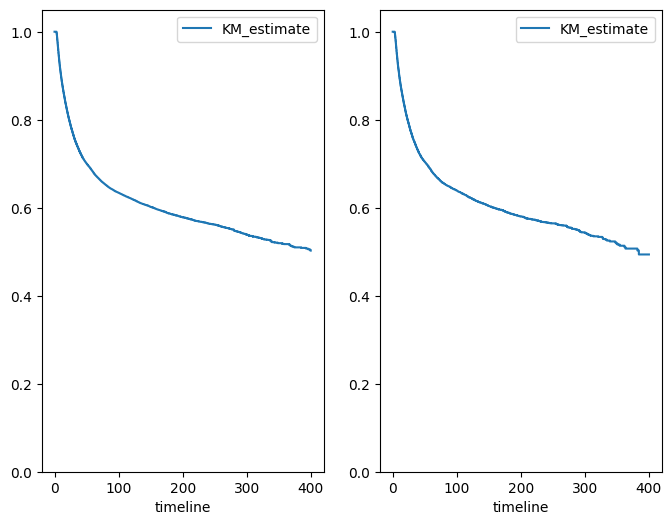

In [4]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (8,6))

km = lifelines.KaplanMeierFitter()
km.fit(df_train["tempo"], df_train["delta"])
km.plot(ax = ax[0], ci_show = False, show_censors = False)
ax[0].set_ylim(0,1.05)

km = lifelines.KaplanMeierFitter()
km.fit(df_test["tempo"], df_test["delta"])
km.plot(ax = ax[1], ci_show = False, show_censors = False)
ax[1].set_ylim(0,1.05)

plt.show()

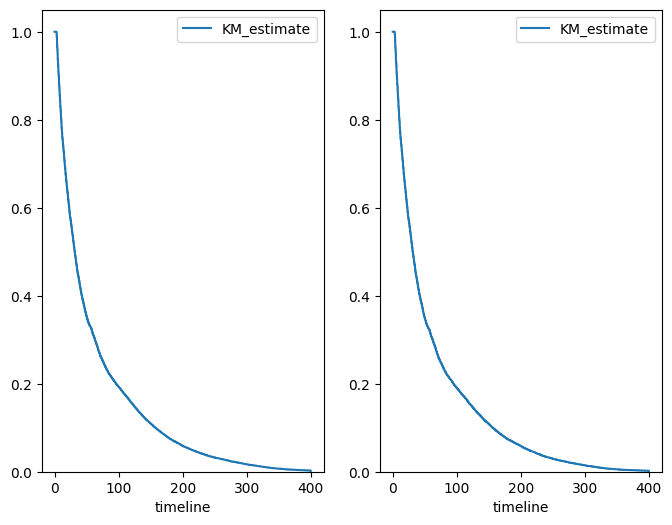

In [5]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (8,6))

km = lifelines.KaplanMeierFitter()
km.fit(df_train["tempo"], 1-df_train["delta"])
km.plot(ax = ax[0], ci_show = False, show_censors = False)
ax[0].set_ylim(0,1.05)

km = lifelines.KaplanMeierFitter()
km.fit(df_test["tempo"], 1-df_test["delta"])
km.plot(ax = ax[1], ci_show = False, show_censors = False)
ax[1].set_ylim(0,1.05)

plt.show()

In [6]:
y_train = df_train["tempo"].to_numpy() / 12
delta_train = df_train["delta"].to_numpy()
data_train = [y_train, delta_train]
X_train = df_train.iloc[:, 2:]

y_test = df_test["tempo"].to_numpy() / 12
delta_test = df_test["delta"].to_numpy()
data_test = [y_test, delta_test]
X_test = df_test.iloc[:, 2:]

In [7]:
linear_columns = [0, 3, 4, 5, 6, 7, 8, 9, 10, 11]
neuralnet_columns = [i for i in np.arange(X_train.shape[1]) if i not in linear_columns]

# ----------------- Train -----------------
# Load linear variables and create interaction between female_sex and races
z_train = X_train.iloc[:, linear_columns].copy()
z_train["sexo_feminino_raca_amarela"] = z_train["sexo_feminino"] * z_train["raca_amarela"]
z_train["sexo_feminino_raca_indigena"] = z_train["sexo_feminino"] * z_train["raca_indigena"]
z_train["sexo_feminino_raca_parda"] = z_train["sexo_feminino"] * z_train["raca_parda"]
z_train["sexo_feminino_raca_preta"] = z_train["sexo_feminino"] * z_train["raca_preta"]
z_train = z_train.loc[:, ["idade", "sexo_feminino",
                          "raca_amarela", "raca_indigena", "raca_parda", "raca_preta",
                          "sexo_feminino_raca_amarela", "sexo_feminino_raca_indigena", "sexo_feminino_raca_parda", "sexo_feminino_raca_preta",
                          "faixa_remuneracao_media_2 a 4 SM", "faixa_remuneracao_media_4 a 7 SM", "faixa_remuneracao_media_até 1 SM", "faixa_remuneracao_media_mais de 7 SM"]]
X_train_nn = X_train.iloc[:, neuralnet_columns]
data_train = [z_train, y_train, delta_train]

# ----------------- Test -----------------
z_test = X_test.iloc[:, linear_columns].copy()
z_test["sexo_feminino_raca_amarela"] = z_test["sexo_feminino"] * z_test["raca_amarela"]
z_test["sexo_feminino_raca_indigena"] = z_test["sexo_feminino"] * z_test["raca_indigena"]
z_test["sexo_feminino_raca_parda"] = z_test["sexo_feminino"] * z_test["raca_parda"]
z_test["sexo_feminino_raca_preta"] = z_test["sexo_feminino"] * z_test["raca_preta"]
z_test = z_test.loc[:, ["idade", "sexo_feminino",
                        "raca_amarela", "raca_indigena", "raca_parda", "raca_preta",
                        "sexo_feminino_raca_amarela", "sexo_feminino_raca_indigena", "sexo_feminino_raca_parda", "sexo_feminino_raca_preta",
                        "faixa_remuneracao_media_2 a 4 SM", "faixa_remuneracao_media_4 a 7 SM", "faixa_remuneracao_media_até 1 SM", "faixa_remuneracao_media_mais de 7 SM"]]
X_test_nn = X_test.iloc[:, neuralnet_columns]
data_test = [z_test, y_test, delta_test]

display( z_train.head(3) )
display( X_train_nn.head(3) )

,idade,sexo_feminino,raca_amarela,raca_indigena,raca_parda,raca_preta,sexo_feminino_raca_amarela,sexo_feminino_raca_indigena,sexo_feminino_raca_parda,sexo_feminino_raca_preta,faixa_remuneracao_media_2 a 4 SM,faixa_remuneracao_media_4 a 7 SM,faixa_remuneracao_media_até 1 SM,faixa_remuneracao_media_mais de 7 SM
0,-1.283593,0,0,0,1,0,0,0,0,0,0,0,0,0
1,-0.582427,0,0,0,0,0,0,0,0,0,0,0,0,0
2,-0.757718,0,0,0,0,0,0,0,0,0,1,0,0,0


,horas_semanais,qtd_dias_afastamento,escolaridade_5 ano completo,escolaridade_6 a 9 ano incompleto,escolaridade_analfabeto,escolaridade_ate 5 ano incompleto,escolaridade_doutorado,escolaridade_fundamental completo,escolaridade_medio incompleto,escolaridade_mestrado,...,tamanho_estabelecimento_de 500 a 999 funcionarios,grupo_ocupacao_cbo_agropecuaria,grupo_ocupacao_cbo_diretores gerentes,grupo_ocupacao_cbo_industria producao,grupo_ocupacao_cbo_manutencao reparacao,grupo_ocupacao_cbo_profissionais nivel superior,grupo_ocupacao_cbo_servicos administrativos,grupo_ocupacao_cbo_tecnicos nivel medio,regime_jornada_jornada intermitente,regime_jornada_jornada parcial
0,0.39963,-0.15985,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0.39963,-0.15985,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0.39963,-0.15985,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [8]:
z_test.columns

Index(['idade', 'sexo_feminino', 'raca_amarela', 'raca_indigena', 'raca_parda',
       'raca_preta', 'sexo_feminino_raca_amarela',
       'sexo_feminino_raca_indigena', 'sexo_feminino_raca_parda',
       'sexo_feminino_raca_preta', 'faixa_remuneracao_media_2 a 4 SM',
       'faixa_remuneracao_media_4 a 7 SM', 'faixa_remuneracao_media_até 1 SM',
       'faixa_remuneracao_media_mais de 7 SM'],
      dtype='object')

## Loading models

In [9]:
seed = 10

# Exponential
exp_parameters, exp_loss = ph.get_simple_model( dist = "exponential", theta_init = None )
simple_exp_model = thf.ModelNN(exp_parameters, exp_loss, None, None, None, input_dim = (X_train_nn.shape[1],), seed = seed)
simple_exp_model.build(None)
simple_exp_model.load_model("Simple_models/Exponential")

# Weibull
weibull_parameters, weibull_loss = ph.get_simple_model( dist = "weibull", theta_init = None )
simple_weibull_model = thf.ModelNN(weibull_parameters, weibull_loss, None, None, None, input_dim = (X_train_nn.shape[1],), seed = seed)
simple_weibull_model.build(None)
simple_weibull_model.load_model("Simple_models/Weibull")

# Log-normal
lognormal_parameters, lognormal_loss = ph.get_simple_model( dist = "lognormal", theta_init = None )
simple_lognormal_model = thf.ModelNN(lognormal_parameters, lognormal_loss, None, None, None, input_dim = (X_train_nn.shape[1],), seed = seed)
simple_lognormal_model.build(None)
simple_lognormal_model.load_model("Simple_models/Lognormal")

# Log-logistic
loglogistic_parameters, loglogistic_loss = ph.get_simple_model( dist = "loglogistic", theta_init = None )
simple_loglogistic_model = thf.ModelNN(loglogistic_parameters, loglogistic_loss, None, None, None, input_dim = (X_train_nn.shape[1],), seed = seed)
simple_loglogistic_model.build(None)
simple_loglogistic_model.load_model("Simple_models/Loglogistic")

# BS
bs_parameters, bs_loss = ph.get_simple_model( dist = "bs", theta_init = None )
simple_bs_model = thf.ModelNN(bs_parameters, bs_loss, None, None, None, input_dim = (X_train_nn.shape[1],), seed = seed)
simple_bs_model.build(None)
simple_bs_model.load_model("Simple_models/BS")

# BCT
bct_parameters, bct_loss = ph.get_simple_model( dist = "bct", theta_init = None )
simple_bct_model = thf.ModelNN(bct_parameters, bct_loss, None, None, None, input_dim = (X_train_nn.shape[1],), seed = seed)
simple_bct_model.build(None)
simple_bct_model.load_model("Simple_models/BCT")

Model successfully loaded from Simple_models/Exponential.
Model successfully loaded from Simple_models/Weibull.
Model successfully loaded from Simple_models/Lognormal.
Model successfully loaded from Simple_models/Loglogistic.
Model successfully loaded from Simple_models/BS.
Model successfully loaded from Simple_models/BCT.


In [10]:
seed = 10

# Exponential
exp_parameters, exp_loss, exp_neural_network, exp_call, exp_call_nolast = ph.build_PH_model( z_train, dist = "exponential", theta_init = None, beta_init = None )
exp_model = thf.ModelNN(exp_parameters, exp_loss, exp_neural_network, exp_call, exp_call_nolast, input_dim = (X_train_nn.shape[1],), seed = seed)
exp_model.load_model("PH_models/Exponential")

# Weibull
weibull_parameters, weibull_loss, weibull_neural_network, weibull_call, weibull_call_nolast = ph.build_PH_model( z_train, dist = "weibull", theta_init = None, beta_init = None )
weibull_model = thf.ModelNN(weibull_parameters, weibull_loss, weibull_neural_network, weibull_call, weibull_call_nolast, input_dim = (X_train_nn.shape[1],), seed = seed)
weibull_model.load_model("PH_models/Weibull")

# Log-normal
lognormal_parameters, lognormal_loss, lognormal_neural_network, lognormal_call, lognormal_call_nolast = ph.build_PH_model( z_train, dist = "lognormal", theta_init = None, beta_init = None )
lognormal_model = thf.ModelNN(lognormal_parameters, lognormal_loss, lognormal_neural_network, lognormal_call, lognormal_call_nolast, input_dim = (X_train_nn.shape[1],), seed = seed)
lognormal_model.load_model("PH_models/Lognormal")

# Log-logistic
loglogistic_parameters, loglogistic_loss, loglogistic_neural_network, loglogistic_call, loglogistic_call_nolast = ph.build_PH_model( z_train, dist = "loglogistic", theta_init = None, beta_init = None )
loglogistic_model = thf.ModelNN(loglogistic_parameters, loglogistic_loss, loglogistic_neural_network, loglogistic_call, loglogistic_call_nolast, input_dim = (X_train_nn.shape[1],), seed = seed)
loglogistic_model.load_model("PH_models/Loglogistic")

# BS
bs_parameters, bs_loss, bs_neural_network, bs_call, bs_call_nolast = ph.build_PH_model( z_train, dist = "bs", theta_init = None, beta_init = None )
bs_model = thf.ModelNN(bs_parameters, bs_loss, bs_neural_network, bs_call, bs_call_nolast, input_dim = (X_train_nn.shape[1],), seed = seed)
bs_model.load_model("PH_models/BS")

# BCT
bct_parameters, bct_loss, bct_neural_network, bct_call, bct_call_nolast = ph.build_PH_model( z_train, dist = "bct", theta_init = None, beta_init = None )
bct_model = thf.ModelNN(bct_parameters, bct_loss, bct_neural_network, bct_call, bct_call_nolast, input_dim = (X_train_nn.shape[1],), seed = seed)
bct_model.load_model("PH_models/BCT")

Model successfully loaded from PH_models/Exponential.
Model successfully loaded from PH_models/Weibull.
Model successfully loaded from PH_models/Lognormal.
Model successfully loaded from PH_models/Loglogistic.
Model successfully loaded from PH_models/BS.
Model successfully loaded from PH_models/BCT.


## Comparing all models - Global Kaplan-Meier

In [11]:
results_simple_exp_test = ph.get_survival_exp(simple_exp_model, y_test, z_test, X_test_nn, y_test, z_test, X_test_nn, ngrid = 100, simple = True)
results_simple_weibull_test = ph.get_survival_weibull(simple_weibull_model, y_test, z_test, X_test_nn, y_test, z_test, X_test_nn, ngrid = 100, simple = True)
results_simple_lognormal_test = ph.get_survival_lognormal(simple_lognormal_model, y_test, z_test, X_test_nn, y_test, z_test, X_test_nn, ngrid = 100, simple = True)
results_simple_loglogistic_test = ph.get_survival_loglogistic(simple_loglogistic_model, y_test, z_test, X_test_nn, y_test, z_test, X_test_nn, ngrid = 100, simple = True)
results_simple_bs_test = ph.get_survival_bs(simple_bs_model, y_test, z_test, X_test_nn, y_test, z_test, X_test_nn, ngrid = 100, simple = True)
results_simple_bct_test = ph.get_survival_bct(simple_bct_model, y_test, z_test, X_test_nn, y_test, z_test, X_test_nn, ngrid = 100, simple = True)

In [12]:
results_exp_test = ph.get_survival_exp(exp_model, y_test, z_test, X_test_nn, y_test, z_test, X_test_nn, ngrid = 100)
results_weibull_test = ph.get_survival_weibull(weibull_model, y_test, z_test, X_test_nn, y_test, z_test, X_test_nn, ngrid = 100)
results_lognormal_test = ph.get_survival_lognormal(lognormal_model, y_test, z_test, X_test_nn, y_test, z_test, X_test_nn, ngrid = 100)
results_loglogistic_test = ph.get_survival_loglogistic(loglogistic_model, y_test, z_test, X_test_nn, y_test, z_test, X_test_nn, ngrid = 100)
results_bs_test = ph.get_survival_bs(bs_model, y_test, z_test, X_test_nn, y_test, z_test, X_test_nn, ngrid = 100)
results_bct_test = ph.get_survival_bct(bct_model, y_test, z_test, X_test_nn, y_test, z_test, X_test_nn, ngrid = 100)

In [22]:
def plot_survival_curves(y_test, delta_test,
                         results_exp_test, results_weibull_test, results_lognormal_test, results_loglogistic_test, results_bs_test, results_bct_test,
                         ax = None, individual_legend = True):
    if(ax is None):
        fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

    km_baseline = lifelines.KaplanMeierFitter()
    km_baseline.fit(y_test, delta_test)
    km_baseline.plot(ax = ax, ci_show = False, show_censors = False, label = "Baseline", color = "black", linestyle = "--")
    ax.set_ylim(0,1.05)
    
    ax.plot(results_exp_test["ts_grid"].flatten(), np.mean( results_exp_test["S_ts_train"], axis = 1 ), color = colors[0], label = "Exp")
    ax.plot(results_weibull_test["ts_grid"].flatten(), np.mean( results_weibull_test["S_ts_train"], axis = 1 ), color = colors[1], label = "Weibull")
    ax.plot(results_lognormal_test["ts_grid"].flatten(), np.mean( results_lognormal_test["S_ts_train"], axis = 1 ), color = colors[2], label = "Lognormal")
    ax.plot(results_loglogistic_test["ts_grid"].flatten(), np.mean( results_loglogistic_test["S_ts_train"], axis = 1 ), color = colors[3], label = "Loglogistic")
    ax.plot(results_bs_test["ts_grid"].flatten(), np.mean( results_bs_test["S_ts_train"], axis = 1 ), color = colors[4], label = "BS")
    ax.plot(results_bct_test["ts_grid"].flatten(), np.mean( results_bct_test["S_ts_train"], axis = 1 ), color = colors[5], label = "BCT")

    if(individual_legend):
        # Custom handles for Line Styles (The Groups)
        group_handles = [
            Line2D([0], [0], color='black', linestyle='--', label='Kaplan-Meier')
        ]
        
        # Custom handles for Colors (The Models)
        model_handles = [
            Line2D([0], [0], color=colors[0], linestyle='-', label='Exp'),
            Line2D([0], [0], color=colors[1], linestyle='-', label='Weibull'),
            Line2D([0], [0], color=colors[2], linestyle='-', label='Log-normal'),
            Line2D([0], [0], color=colors[3], linestyle='-', label='Log-logistic'),
            Line2D([0], [0], color=colors[4], linestyle='-', label='BS'),
            Line2D([0], [0], color=colors[5], linestyle='-', label='BCT')
        ]
        
        # Add the first legend (Groups) - Anchored to the top left
        legend1 = ax.legend(
            handles = group_handles, 
            loc = 'lower left', 
            bbox_to_anchor = (0.0, 1.08), # Pushes it just above the top-left corner
            title = "Non-parametric",
            ncol = 2                     # Lays items out horizontally
        )
        
        ax.add_artist(legend1) 
        
        # Add the second legend (Models) - Anchored to the top right
        ax.legend(
            handles = model_handles, 
            loc = 'lower right', 
            bbox_to_anchor = (1.0, 1.08), # Pushes it just above the top-right corner
            title = "Parametric",
            ncol = 3,                     # Lays items out horizontally
        )
        
        # Prevent the top legends from being clipped off the final image
        plt.tight_layout() 

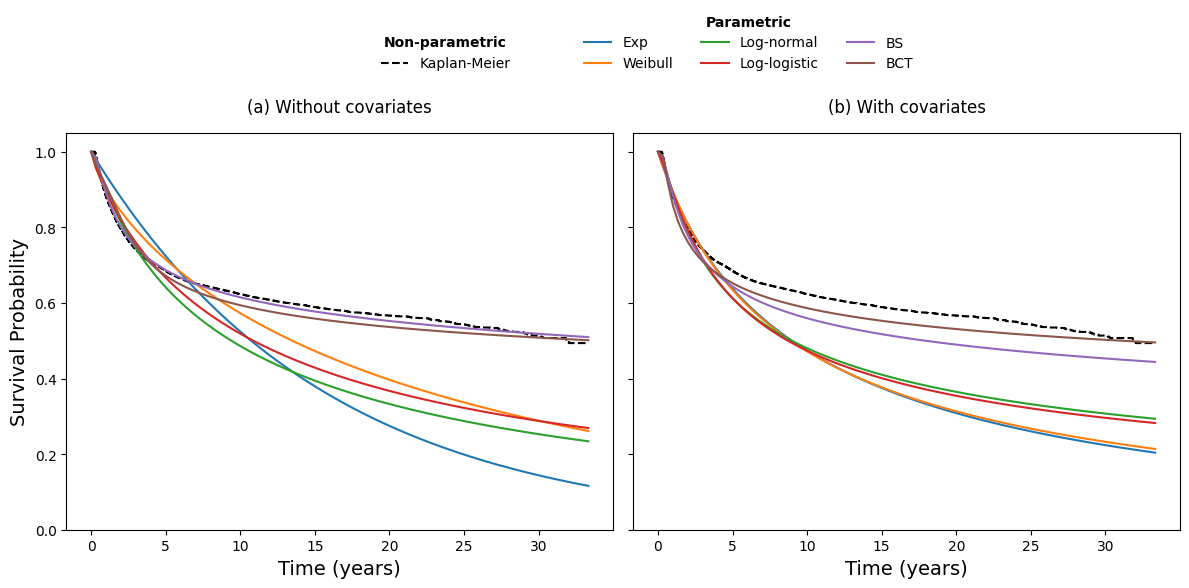

In [23]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6), sharey=True)

plot_survival_curves(y_test, delta_test,
                     results_simple_exp_test, results_simple_weibull_test, results_simple_lognormal_test, results_simple_loglogistic_test, results_simple_bs_test, results_simple_bct_test,
                     ax=ax[0], individual_legend = False)

plot_survival_curves(y_test, delta_test,
                     results_exp_test, results_weibull_test, results_lognormal_test, results_loglogistic_test, results_bs_test, results_bct_test,
                     ax=ax[1], individual_legend = False)

ax[0].set_xlabel("Time (years)", fontsize=14)
ax[0].set_ylabel("Survival Probability", fontsize=14)
ax[0].set_title("(a) Without covariates", pad=15)

ax[1].set_xlabel("Time (years)", fontsize=14)
ax[1].set_ylabel("")
ax[1].set_title("(b) With covariates", pad = 15)

for a in ax:
    leg = a.get_legend()
    if leg is not None:
        leg.remove()

# 4. Global Legend Definitions
group_handles = [
    Line2D([0], [0], color='black', linestyle='--', label='Kaplan-Meier')
]

model_handles = [
    Line2D([0], [0], color=colors[0], linestyle='-', label='Exp'),
    Line2D([0], [0], color=colors[1], linestyle='-', label='Weibull'),
    Line2D([0], [0], color=colors[2], linestyle='-', label='Log-normal'),
    Line2D([0], [0], color=colors[3], linestyle='-', label='Log-logistic'),
    Line2D([0], [0], color=colors[4], linestyle='-', label='BS'),
    Line2D([0], [0], color=colors[5], linestyle='-', label='BCT')
]

# 5. Master Layout Engine
# Reserve the top 15% of the figure to safely house our two titles and labels
fig.tight_layout(rect=[0, 0, 1, 0.85])

# Left Legend (Non-parametric) - Anchored at x=0.48, pushing rightwards toward center
leg1 = fig.legend(
    handles=group_handles, 
    loc='lower right', 
    bbox_to_anchor=(0.44, 0.85), 
    title="Non-parametric",
    frameon=False
)
leg1.get_title().set_fontweight('bold') # Extra polish

# Right Legend (Parametric) - Anchored at x=0.52, pushing leftwards toward center
leg2 = fig.legend(
    handles=model_handles, 
    loc='lower left', 
    bbox_to_anchor=(0.48, 0.85), 
    title="Parametric",
    ncol=3, 
    frameon=False
)
leg2.get_title().set_fontweight('bold') # Extra polish

# 6. Protected Export
# We must pass both leg1 and leg2 to bbox_extra_artists to prevent cropping
fig.savefig('../Images/kaplan_meier_survival_curves.png', format='png', dpi=300, 
            bbox_inches='tight', bbox_extra_artists=(leg1, leg2))
fig.savefig('../Images/kaplan_meier_survival_curves.pdf', format='pdf', dpi=300, 
            bbox_inches='tight', bbox_extra_artists=(leg1, leg2))

plt.show()

In [15]:
ts_grid = results_exp_test["ts_grid"]

km_baseline = lifelines.KaplanMeierFitter()
km_baseline.fit(y_test, delta_test)

km_t = km_baseline.survival_function_at_times(ts_grid.flatten())
rmse_km_simple_exp = np.sqrt( np.mean(km_t - np.mean( results_simple_exp_test["S_ts_train"], axis = 1 ))**2 )
rmse_km_simple_weibull = np.sqrt( np.mean(km_t - np.mean( results_simple_weibull_test["S_ts_train"], axis = 1 ))**2 )
rmse_km_simple_lognormal = np.sqrt( np.mean(km_t - np.mean( results_simple_lognormal_test["S_ts_train"], axis = 1 ))**2 )
rmse_km_simple_loglogstic = np.sqrt( np.mean(km_t - np.mean( results_simple_loglogistic_test["S_ts_train"], axis = 1 ))**2 )
rmse_km_simple_bs = np.sqrt( np.mean(km_t - np.mean( results_simple_bs_test["S_ts_train"], axis = 1 ))**2 )
rmse_km_simple_bct = np.sqrt( np.mean(km_t - np.mean( results_simple_bct_test["S_ts_train"], axis = 1 ))**2 )

print("----- RMSE-KM: Models without covariates -----")
print("Exp:", np.round(rmse_km_simple_exp, 4))
print("Weibull:", np.round(rmse_km_simple_weibull, 4))
print("Lognormal:", np.round(rmse_km_simple_lognormal, 4))
print("Loglogistic:", np.round(rmse_km_simple_loglogstic, 4))
print("BS:", np.round(rmse_km_simple_bs, 4))
print("BCT:", np.round(rmse_km_simple_bct, 4))

----- RMSE-KM: Models without covariates -----
Exp: 0.1963
Weibull: 0.1147
Lognormal: 0.1732
Loglogistic: 0.1434
BS: 0.0045
BCT: 0.0172


In [16]:
ts_grid = results_exp_test["ts_grid"]

km_t = km_baseline.survival_function_at_times(ts_grid.flatten())
rmse_km_exp = np.sqrt( np.mean(km_t - np.mean( results_exp_test["S_ts_train"], axis = 1 ))**2 )
rmse_km_weibull = np.sqrt( np.mean(km_t - np.mean( results_weibull_test["S_ts_train"], axis = 1 ))**2 )
rmse_km_lognormal = np.sqrt( np.mean(km_t - np.mean( results_lognormal_test["S_ts_train"], axis = 1 ))**2 )
rmse_km_loglogstic = np.sqrt( np.mean(km_t - np.mean( results_loglogistic_test["S_ts_train"], axis = 1 ))**2 )
rmse_km_bs = np.sqrt( np.mean(km_t - np.mean( results_bs_test["S_ts_train"], axis = 1 ))**2 )
rmse_km_bct = np.sqrt( np.mean(km_t - np.mean( results_bct_test["S_ts_train"], axis = 1 ))**2 )

print("----- RMSE-KM: Models with covariates -----")
print("Exp:", np.round(rmse_km_exp, 4))
print("Weibull:", np.round(rmse_km_weibull, 4))
print("Lognormal:", np.round(rmse_km_lognormal, 4))
print("Loglogistic:", np.round(rmse_km_loglogstic, 4))
print("BS:", np.round(rmse_km_bs, 4))
print("BCT:", np.round(rmse_km_bct, 4))

----- RMSE-KM: Models with covariates -----
Exp: 0.1918
Weibull: 0.1888
Lognormal: 0.1556
Loglogistic: 0.163
BS: 0.0591
BCT: 0.0282


## Comparing all models - Até 1 SM

In [17]:
X_train.head(1)

,idade,horas_semanais,qtd_dias_afastamento,sexo_feminino,raca_amarela,raca_indigena,raca_parda,raca_preta,faixa_remuneracao_media_2 a 4 SM,faixa_remuneracao_media_4 a 7 SM,...,tamanho_estabelecimento_de 500 a 999 funcionarios,grupo_ocupacao_cbo_agropecuaria,grupo_ocupacao_cbo_diretores gerentes,grupo_ocupacao_cbo_industria producao,grupo_ocupacao_cbo_manutencao reparacao,grupo_ocupacao_cbo_profissionais nivel superior,grupo_ocupacao_cbo_servicos administrativos,grupo_ocupacao_cbo_tecnicos nivel medio,regime_jornada_jornada intermitente,regime_jornada_jornada parcial
0,-1.283593,0.39963,-0.15985,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [18]:
# Takes only employees whose sallary is the standard (between 1 and 2 minimal salaries)
baseline_idx = (X_train.iloc[:, [8,9,10,11]] == 0).all(axis = 1)
X_baseline = X_train.loc[ baseline_idx , : ]
y_baseline = y_train[ baseline_idx ]
delta_baseline = delta_train[ baseline_idx ]

z_baseline = X_baseline.iloc[:, linear_columns]
z_baseline_tf = tf.cast(z_baseline, tf.float32)
X_baseline_nn = X_baseline.iloc[:, neuralnet_columns]
# y_baseline = 

ate1sm_idx = X_train["faixa_remuneracao_media_até 1 SM"] == 1
X_ate1sm = X_train.loc[ ate1sm_idx , : ]
y_ate1sm = y_train[ ate1sm_idx ]
delta_ate1sm = delta_train[ ate1sm_idx ]

z_ate1sm = X_ate1sm.iloc[:, linear_columns]
z_ate1sm_tf = tf.cast(z_ate1sm, tf.float32)
X_ate1sm_nn = X_ate1sm.iloc[:, neuralnet_columns]

In [19]:
# Takes only employees whose sallary is the standard (between 1 and 2 minimal salaries)
baseline_idx = (X_train.iloc[:, [8,9,10,11]] == 0).all(axis = 1)
y_baseline = y_train[ baseline_idx ]
delta_baseline = delta_train[ baseline_idx ]

z_baseline = z_train.loc[baseline_idx, :]
z_baseline_tf = tf.cast(z_baseline, tf.float32)
X_baseline_nn = X_train_nn.loc[baseline_idx, :]
# y_baseline = 

ate1sm_idx = X_train["faixa_remuneracao_media_até 1 SM"] == 1
y_ate1sm = y_train[ ate1sm_idx ]
delta_ate1sm = delta_train[ ate1sm_idx ]

z_ate1sm = z_train.loc[ate1sm_idx, :]
z_ate1sm_tf = tf.cast(z_ate1sm, tf.float32)
X_ate1sm_nn = X_train_nn.loc[ate1sm_idx, :]

In [20]:
results_exp_baseline = ph.get_survival_exp(exp_model, y_baseline, z_baseline_tf, X_baseline_nn, y_baseline, z_baseline_tf, X_baseline_nn, ngrid = 100)
results_exp_ate1sm = ph.get_survival_exp(exp_model, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, ngrid = 100)

results_weibull_baseline = ph.get_survival_weibull(weibull_model, y_baseline, z_baseline_tf, X_baseline_nn, y_baseline, z_baseline_tf, X_baseline_nn, ngrid = 100)
results_weibull_ate1sm = ph.get_survival_weibull(weibull_model, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, ngrid = 100)

results_lognormal_baseline = ph.get_survival_lognormal(lognormal_model, y_baseline, z_baseline_tf, X_baseline_nn, y_baseline, z_baseline_tf, X_baseline_nn, ngrid = 100)
results_lognormal_ate1sm = ph.get_survival_lognormal(lognormal_model, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, ngrid = 100)

results_loglogistic_baseline = ph.get_survival_loglogistic(loglogistic_model, y_baseline, z_baseline_tf, X_baseline_nn, y_baseline, z_baseline_tf, X_baseline_nn, ngrid = 100)
results_loglogistic_ate1sm = ph.get_survival_loglogistic(loglogistic_model, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, ngrid = 100)

results_bs_baseline = ph.get_survival_bs(bs_model, y_baseline, z_baseline_tf, X_baseline_nn, y_baseline, z_baseline_tf, X_baseline_nn, ngrid = 100)
results_bs_ate1sm = ph.get_survival_bs(bs_model, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, ngrid = 100)

results_bct_baseline = ph.get_survival_bct(bct_model, y_baseline, z_baseline_tf, X_baseline_nn, y_baseline, z_baseline_tf, X_baseline_nn, ngrid = 100)
results_bct_ate1sm = ph.get_survival_bct(bct_model, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, ngrid = 100)

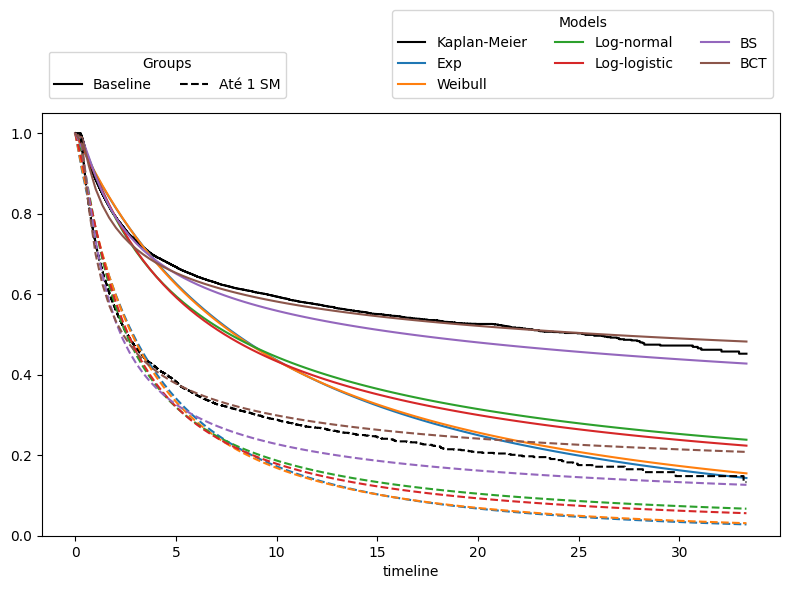

In [21]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

# ax.plot(ts_grid.numpy().flatten(), np.mean( S_ts_baseline, axis = 1 ), color = colors[0])

km_baseline = lifelines.KaplanMeierFitter()
km_baseline.fit(y_baseline, delta_baseline)
km_baseline.plot(ax = ax, ci_show = False, show_censors = False, label = "Baseline", color = "black", linestyle = "-")
ax.set_ylim(0,1.05)

ax.plot(results_exp_baseline["ts_grid"].flatten(), np.mean( results_exp_baseline["S_ts_train"], axis = 1 ), color = colors[0], label = "Exp")
ax.plot(results_weibull_baseline["ts_grid"].flatten(), np.mean( results_weibull_baseline["S_ts_train"], axis = 1 ), color = colors[1], label = "Weibull")
ax.plot(results_lognormal_baseline["ts_grid"].flatten(), np.mean( results_lognormal_baseline["S_ts_train"], axis = 1 ), color = colors[2], label = "Lognormal")
ax.plot(results_loglogistic_baseline["ts_grid"].flatten(), np.mean( results_loglogistic_baseline["S_ts_train"], axis = 1 ), color = colors[3], label = "Loglogistic")
ax.plot(results_bs_baseline["ts_grid"].flatten(), np.mean( results_bs_baseline["S_ts_train"], axis = 1 ), color = colors[4], label = "BS")
ax.plot(results_bct_baseline["ts_grid"].flatten(), np.mean( results_bct_baseline["S_ts_train"], axis = 1 ), color = colors[5], label = "BCT")

km_ate1sm = lifelines.KaplanMeierFitter()
km_ate1sm.fit(y_ate1sm, delta_ate1sm)
km_ate1sm.plot(ax = ax, ci_show = False, show_censors = False, label = "Até 1 SM", color = "black", linestyle = "--")
ax.set_ylim(0,1.05)

ax.plot(results_exp_ate1sm["ts_grid"].flatten(), np.mean( results_exp_ate1sm["S_ts_train"], axis = 1 ), color = colors[0], linestyle = "--")
ax.plot(results_weibull_ate1sm["ts_grid"].flatten(), np.mean( results_weibull_ate1sm["S_ts_train"], axis = 1 ), color = colors[1], linestyle = "--")
ax.plot(results_lognormal_ate1sm["ts_grid"].flatten(), np.mean( results_lognormal_ate1sm["S_ts_train"], axis = 1 ), color = colors[2], linestyle = "--")
ax.plot(results_loglogistic_ate1sm["ts_grid"].flatten(), np.mean( results_loglogistic_ate1sm["S_ts_train"], axis = 1 ), color = colors[3], linestyle = "--")
ax.plot(results_bs_ate1sm["ts_grid"].flatten(), np.mean( results_bs_ate1sm["S_ts_train"], axis = 1 ), color = colors[4], linestyle = "--")
ax.plot(results_bct_ate1sm["ts_grid"].flatten(), np.mean( results_bct_ate1sm["S_ts_train"], axis = 1 ), color = colors[5], linestyle = "--")

# Custom handles for Line Styles (The Groups)
group_handles = [
    Line2D([0], [0], color='black', linestyle='-', label='Baseline'),
    Line2D([0], [0], color='black', linestyle='--', label='Até 1 SM')
]

# Custom handles for Colors (The Models)
model_handles = [
    Line2D([0], [0], color='black', linestyle='-', label='Kaplan-Meier'),
    Line2D([0], [0], color=colors[0], linestyle='-', label='Exp'),
    Line2D([0], [0], color=colors[1], linestyle='-', label='Weibull'),
    Line2D([0], [0], color=colors[2], linestyle='-', label='Log-normal'),
    Line2D([0], [0], color=colors[3], linestyle='-', label='Log-logistic'),
    Line2D([0], [0], color=colors[4], linestyle='-', label='BS'),
    Line2D([0], [0], color=colors[5], linestyle='-', label='BCT')
]

# Add the first legend (Groups) - Anchored to the top left
legend1 = ax.legend(
    handles = group_handles, 
    loc = 'lower left', 
    bbox_to_anchor = (0.0, 1.02), # Pushes it just above the top-left corner
    title = "Groups",
    ncol = 2                     # Lays items out horizontally
)

ax.add_artist(legend1) 

# Add the second legend (Models) - Anchored to the top right
ax.legend(
    handles = model_handles, 
    loc = 'lower right', 
    bbox_to_anchor = (1.0, 1.02), # Pushes it just above the top-right corner
    title = "Models",
    ncol = 3,                     # Lays items out horizontally
)

# Prevent the top legends from being clipped off the final image
plt.tight_layout() 
plt.show()

## Comparing all models - Raça Preta

In [22]:
X_train.head(1)

,idade,horas_semanais,qtd_dias_afastamento,sexo_feminino,raca_amarela,raca_indigena,raca_parda,raca_preta,faixa_remuneracao_media_2 a 4 SM,faixa_remuneracao_media_4 a 7 SM,...,tamanho_estabelecimento_de 500 a 999 funcionarios,grupo_ocupacao_cbo_agropecuaria,grupo_ocupacao_cbo_diretores gerentes,grupo_ocupacao_cbo_industria producao,grupo_ocupacao_cbo_manutencao reparacao,grupo_ocupacao_cbo_profissionais nivel superior,grupo_ocupacao_cbo_servicos administrativos,grupo_ocupacao_cbo_tecnicos nivel medio,regime_jornada_jornada intermitente,regime_jornada_jornada parcial
0,-1.283593,0.39963,-0.15985,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [23]:
# Takes only employees whose race is white
baseline_raca_idx = (X_train.iloc[:, [4,5,6,7]] == 0).all(axis = 1)

y_baseline_raca = y_train[ baseline_raca_idx ]
delta_baseline_raca = delta_train[ baseline_raca_idx ]

z_baseline_raca = z_train.loc[baseline_raca_idx,:]
z_baseline_raca_tf = tf.cast(z_baseline_raca, tf.float32)
X_baseline_raca_nn = X_train_nn.loc[baseline_raca_idx, :]

racapreta_idx = X_train["raca_preta"] == 1

y_racapreta = y_train[ racapreta_idx ]
delta_racapreta = delta_train[ racapreta_idx ]

z_racapreta = z_train.loc[racapreta_idx, :]
z_racapreta_tf = tf.cast(z_racapreta, tf.float32)
X_racapreta_nn = X_train_nn.loc[racapreta_idx, :]

In [24]:
results_exp_baseline_raca = ph.get_survival_exp(exp_model, y_baseline_raca, z_baseline_raca_tf, X_baseline_raca_nn, y_baseline_raca, z_baseline_raca_tf, X_baseline_raca_nn, ngrid = 100)
results_exp_racapreta = ph.get_survival_exp(exp_model, y_racapreta, z_racapreta_tf, X_racapreta_nn, y_racapreta, z_racapreta_tf, X_racapreta_nn, ngrid = 100)

results_weibull_baseline_raca = ph.get_survival_weibull(weibull_model, y_baseline_raca, z_baseline_raca_tf, X_baseline_raca_nn, y_baseline_raca, z_baseline_raca_tf, X_baseline_raca_nn, ngrid = 100)
results_weibull_racapreta = ph.get_survival_weibull(weibull_model, y_racapreta, z_racapreta_tf, X_racapreta_nn, y_racapreta, z_racapreta_tf, X_racapreta_nn, ngrid = 100)

results_lognormal_baseline_raca = ph.get_survival_lognormal(lognormal_model, y_baseline_raca, z_baseline_raca_tf, X_baseline_raca_nn, y_baseline_raca, z_baseline_raca_tf, X_baseline_raca_nn, ngrid = 100)
results_lognormal_racapreta = ph.get_survival_lognormal(lognormal_model, y_racapreta, z_racapreta_tf, X_racapreta_nn, y_racapreta, z_racapreta_tf, X_racapreta_nn, ngrid = 100)

results_loglogistic_baseline_raca = ph.get_survival_loglogistic(loglogistic_model, y_baseline_raca, z_baseline_raca_tf, X_baseline_raca_nn, y_baseline_raca, z_baseline_raca_tf, X_baseline_raca_nn, ngrid = 100)
results_loglogistic_racapreta = ph.get_survival_loglogistic(loglogistic_model, y_racapreta, z_racapreta_tf, X_racapreta_nn, y_racapreta, z_racapreta_tf, X_racapreta_nn, ngrid = 100)

results_bs_baseline_raca = ph.get_survival_bs(bs_model, y_baseline_raca, z_baseline_raca_tf, X_baseline_raca_nn, y_baseline_raca, z_baseline_raca_tf, X_baseline_raca_nn, ngrid = 100)
results_bs_racapreta = ph.get_survival_bs(bs_model, y_racapreta, z_racapreta_tf, X_racapreta_nn, y_racapreta, z_racapreta_tf, X_racapreta_nn, ngrid = 100)

results_bct_baseline_raca = ph.get_survival_bct(bct_model, y_baseline_raca, z_baseline_raca_tf, X_baseline_raca_nn, y_baseline_raca, z_baseline_raca_tf, X_baseline_raca_nn, ngrid = 100)
results_bct_racapreta = ph.get_survival_bct(bct_model, y_racapreta, z_racapreta_tf, X_racapreta_nn, y_racapreta, z_racapreta_tf, X_racapreta_nn, ngrid = 100)

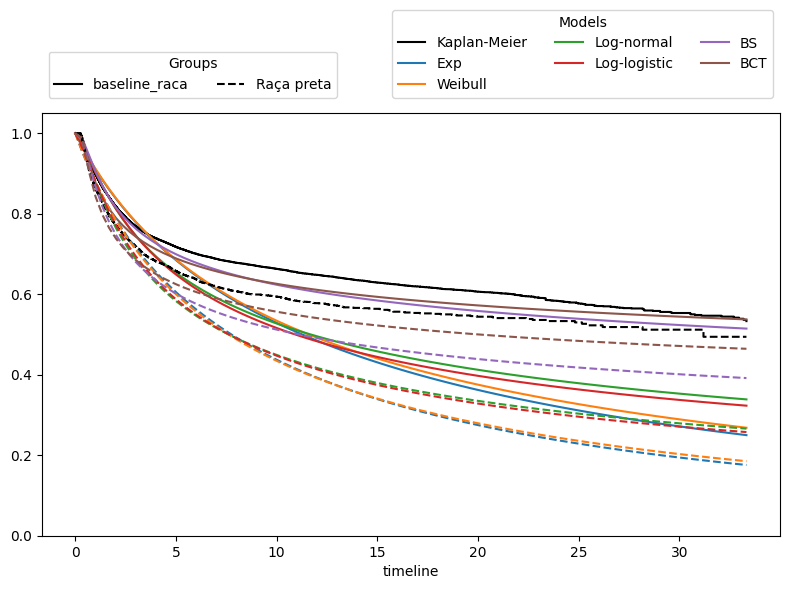

In [25]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

# ax.plot(ts_grid.numpy().flatten(), np.mean( S_ts_baseline_raca, axis = 1 ), color = colors[0])

km_baseline_raca = lifelines.KaplanMeierFitter()
km_baseline_raca.fit(y_baseline_raca, delta_baseline_raca)
km_baseline_raca.plot(ax = ax, ci_show = False, show_censors = False, label = "baseline_raca", color = "black", linestyle = "-")
ax.set_ylim(0,1.05)

ax.plot(results_exp_baseline_raca["ts_grid"].flatten(), np.mean( results_exp_baseline_raca["S_ts_train"], axis = 1 ), color = colors[0], label = "Exp")
ax.plot(results_weibull_baseline_raca["ts_grid"].flatten(), np.mean( results_weibull_baseline_raca["S_ts_train"], axis = 1 ), color = colors[1], label = "Weibull")
ax.plot(results_lognormal_baseline_raca["ts_grid"].flatten(), np.mean( results_lognormal_baseline_raca["S_ts_train"], axis = 1 ), color = colors[2], label = "Lognormal")
ax.plot(results_loglogistic_baseline_raca["ts_grid"].flatten(), np.mean( results_loglogistic_baseline_raca["S_ts_train"], axis = 1 ), color = colors[3], label = "Loglogistic")
ax.plot(results_bs_baseline_raca["ts_grid"].flatten(), np.mean( results_bs_baseline_raca["S_ts_train"], axis = 1 ), color = colors[4], label = "BS")
ax.plot(results_bct_baseline_raca["ts_grid"].flatten(), np.mean( results_bct_baseline_raca["S_ts_train"], axis = 1 ), color = colors[5], label = "BCT")

km_racapreta = lifelines.KaplanMeierFitter()
km_racapreta.fit(y_racapreta, delta_racapreta)
km_racapreta.plot(ax = ax, ci_show = False, show_censors = False, label = "Até 1 SM", color = "black", linestyle = "--")
ax.set_ylim(0,1.05)

ax.plot(results_exp_racapreta["ts_grid"].flatten(), np.mean( results_exp_racapreta["S_ts_train"], axis = 1 ), color = colors[0], linestyle = "--")
ax.plot(results_weibull_racapreta["ts_grid"].flatten(), np.mean( results_weibull_racapreta["S_ts_train"], axis = 1 ), color = colors[1], linestyle = "--")
ax.plot(results_lognormal_racapreta["ts_grid"].flatten(), np.mean( results_lognormal_racapreta["S_ts_train"], axis = 1 ), color = colors[2], linestyle = "--")
ax.plot(results_loglogistic_racapreta["ts_grid"].flatten(), np.mean( results_loglogistic_racapreta["S_ts_train"], axis = 1 ), color = colors[3], linestyle = "--")
ax.plot(results_bs_racapreta["ts_grid"].flatten(), np.mean( results_bs_racapreta["S_ts_train"], axis = 1 ), color = colors[4], linestyle = "--")
ax.plot(results_bct_racapreta["ts_grid"].flatten(), np.mean( results_bct_racapreta["S_ts_train"], axis = 1 ), color = colors[5], linestyle = "--")

# Custom handles for Line Styles (The Groups)
group_handles = [
    Line2D([0], [0], color='black', linestyle='-', label='baseline_raca'),
    Line2D([0], [0], color='black', linestyle='--', label='Raça preta')
]

# Custom handles for Colors (The Models)
model_handles = [
    Line2D([0], [0], color='black', linestyle='-', label='Kaplan-Meier'),
    Line2D([0], [0], color=colors[0], linestyle='-', label='Exp'),
    Line2D([0], [0], color=colors[1], linestyle='-', label='Weibull'),
    Line2D([0], [0], color=colors[2], linestyle='-', label='Log-normal'),
    Line2D([0], [0], color=colors[3], linestyle='-', label='Log-logistic'),
    Line2D([0], [0], color=colors[4], linestyle='-', label='BS'),
    Line2D([0], [0], color=colors[5], linestyle='-', label='BCT')
]

# Add the first legend (Groups) - Anchored to the top left
legend1 = ax.legend(
    handles = group_handles, 
    loc = 'lower left', 
    bbox_to_anchor = (0.0, 1.02), # Pushes it just above the top-left corner
    title = "Groups",
    ncol = 2                     # Lays items out horizontally
)

ax.add_artist(legend1) 

# Add the second legend (Models) - Anchored to the top right
ax.legend(
    handles = model_handles, 
    loc = 'lower right', 
    bbox_to_anchor = (1.0, 1.02), # Pushes it just above the top-right corner
    title = "Models",
    ncol = 3,                     # Lays items out horizontally
)

# Prevent the top legends from being clipped off the final image
plt.tight_layout() 
plt.show()

## Comparing all models - Sexo feminino

In [26]:
X_train.head(1)

,idade,horas_semanais,qtd_dias_afastamento,sexo_feminino,raca_amarela,raca_indigena,raca_parda,raca_preta,faixa_remuneracao_media_2 a 4 SM,faixa_remuneracao_media_4 a 7 SM,...,tamanho_estabelecimento_de 500 a 999 funcionarios,grupo_ocupacao_cbo_agropecuaria,grupo_ocupacao_cbo_diretores gerentes,grupo_ocupacao_cbo_industria producao,grupo_ocupacao_cbo_manutencao reparacao,grupo_ocupacao_cbo_profissionais nivel superior,grupo_ocupacao_cbo_servicos administrativos,grupo_ocupacao_cbo_tecnicos nivel medio,regime_jornada_jornada intermitente,regime_jornada_jornada parcial
0,-1.283593,0.39963,-0.15985,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [27]:
# Takes only employees that are female
baseline_sexo_idx = (X_train.iloc[:, [3]] == 0).all(axis = 1)

y_baseline_sexo = y_train[ baseline_sexo_idx ]
delta_baseline_sexo = delta_train[ baseline_sexo_idx ]

z_baseline_sexo = z_train.loc[baseline_sexo_idx,:]
z_baseline_sexo_tf = tf.cast(z_baseline_sexo, tf.float32)
X_baseline_sexo_nn = X_train_nn.loc[baseline_sexo_idx, :]

sexofeminino_idx = X_train["sexo_feminino"] == 1

y_sexofeminino = y_train[ sexofeminino_idx ]
delta_sexofeminino = delta_train[ sexofeminino_idx ]

z_sexofeminino = z_train.loc[sexofeminino_idx, :]
z_sexofeminino_tf = tf.cast(z_sexofeminino, tf.float32)
X_sexofeminino_nn = X_train_nn.loc[sexofeminino_idx, :]

In [28]:
results_exp_baseline_sexo = ph.get_survival_exp(exp_model, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, ngrid = 100)
results_exp_sexofeminino = ph.get_survival_exp(exp_model, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, ngrid = 100)

results_weibull_baseline_sexo = ph.get_survival_weibull(weibull_model, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, ngrid = 100)
results_weibull_sexofeminino = ph.get_survival_weibull(weibull_model, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, ngrid = 100)

results_lognormal_baseline_sexo = ph.get_survival_lognormal(lognormal_model, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, ngrid = 100)
results_lognormal_sexofeminino = ph.get_survival_lognormal(lognormal_model, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, ngrid = 100)

results_loglogistic_baseline_sexo = ph.get_survival_loglogistic(loglogistic_model, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, ngrid = 100)
results_loglogistic_sexofeminino = ph.get_survival_loglogistic(loglogistic_model, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, ngrid = 100)

results_bs_baseline_sexo = ph.get_survival_bs(bs_model, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, ngrid = 100)
results_bs_sexofeminino = ph.get_survival_bs(bs_model, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, ngrid = 100)

results_bct_baseline_sexo = ph.get_survival_bct(bct_model, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, y_baseline_sexo, z_baseline_sexo_tf, X_baseline_sexo_nn, ngrid = 100)
results_bct_sexofeminino = ph.get_survival_bct(bct_model, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, y_sexofeminino, z_sexofeminino_tf, X_sexofeminino_nn, ngrid = 100)

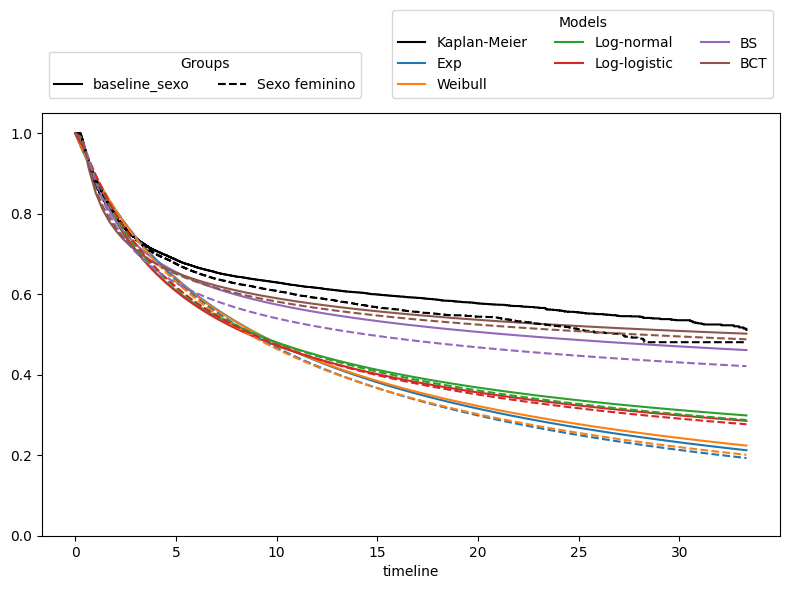

In [29]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

# ax.plot(ts_grid.numpy().flatten(), np.mean( S_ts_baseline_sexo, axis = 1 ), color = colors[0])

km_baseline_sexo = lifelines.KaplanMeierFitter()
km_baseline_sexo.fit(y_baseline_sexo, delta_baseline_sexo)
km_baseline_sexo.plot(ax = ax, ci_show = False, show_censors = False, label = "baseline_sexo", color = "black", linestyle = "-")
ax.set_ylim(0,1.05)

ax.plot(results_exp_baseline_sexo["ts_grid"].flatten(), np.mean( results_exp_baseline_sexo["S_ts_train"], axis = 1 ), color = colors[0], label = "Exp")
ax.plot(results_weibull_baseline_sexo["ts_grid"].flatten(), np.mean( results_weibull_baseline_sexo["S_ts_train"], axis = 1 ), color = colors[1], label = "Weibull")
ax.plot(results_lognormal_baseline_sexo["ts_grid"].flatten(), np.mean( results_lognormal_baseline_sexo["S_ts_train"], axis = 1 ), color = colors[2], label = "Lognormal")
ax.plot(results_loglogistic_baseline_sexo["ts_grid"].flatten(), np.mean( results_loglogistic_baseline_sexo["S_ts_train"], axis = 1 ), color = colors[3], label = "Loglogistic")
ax.plot(results_bs_baseline_sexo["ts_grid"].flatten(), np.mean( results_bs_baseline_sexo["S_ts_train"], axis = 1 ), color = colors[4], label = "BS")
ax.plot(results_bct_baseline_sexo["ts_grid"].flatten(), np.mean( results_bct_baseline_sexo["S_ts_train"], axis = 1 ), color = colors[5], label = "BCT")

km_sexofeminino = lifelines.KaplanMeierFitter()
km_sexofeminino.fit(y_sexofeminino, delta_sexofeminino)
km_sexofeminino.plot(ax = ax, ci_show = False, show_censors = False, label = "Sexo feminino", color = "black", linestyle = "--")
ax.set_ylim(0,1.05)

ax.plot(results_exp_sexofeminino["ts_grid"].flatten(), np.mean( results_exp_sexofeminino["S_ts_train"], axis = 1 ), color = colors[0], linestyle = "--")
ax.plot(results_weibull_sexofeminino["ts_grid"].flatten(), np.mean( results_weibull_sexofeminino["S_ts_train"], axis = 1 ), color = colors[1], linestyle = "--")
ax.plot(results_lognormal_sexofeminino["ts_grid"].flatten(), np.mean( results_lognormal_sexofeminino["S_ts_train"], axis = 1 ), color = colors[2], linestyle = "--")
ax.plot(results_loglogistic_sexofeminino["ts_grid"].flatten(), np.mean( results_loglogistic_sexofeminino["S_ts_train"], axis = 1 ), color = colors[3], linestyle = "--")
ax.plot(results_bs_sexofeminino["ts_grid"].flatten(), np.mean( results_bs_sexofeminino["S_ts_train"], axis = 1 ), color = colors[4], linestyle = "--")
ax.plot(results_bct_sexofeminino["ts_grid"].flatten(), np.mean( results_bct_sexofeminino["S_ts_train"], axis = 1 ), color = colors[5], linestyle = "--")

# Custom handles for Line Styles (The Groups)
group_handles = [
    Line2D([0], [0], color='black', linestyle='-', label='baseline_sexo'),
    Line2D([0], [0], color='black', linestyle='--', label='Sexo feminino')
]

# Custom handles for Colors (The Models)
model_handles = [
    Line2D([0], [0], color='black', linestyle='-', label='Kaplan-Meier'),
    Line2D([0], [0], color=colors[0], linestyle='-', label='Exp'),
    Line2D([0], [0], color=colors[1], linestyle='-', label='Weibull'),
    Line2D([0], [0], color=colors[2], linestyle='-', label='Log-normal'),
    Line2D([0], [0], color=colors[3], linestyle='-', label='Log-logistic'),
    Line2D([0], [0], color=colors[4], linestyle='-', label='BS'),
    Line2D([0], [0], color=colors[5], linestyle='-', label='BCT')
]

# Add the first legend (Groups) - Anchored to the top left
legend1 = ax.legend(
    handles = group_handles, 
    loc = 'lower left', 
    bbox_to_anchor = (0.0, 1.02), # Pushes it just above the top-left corner
    title = "Groups",
    ncol = 2                     # Lays items out horizontally
)

ax.add_artist(legend1) 

# Add the second legend (Models) - Anchored to the top right
ax.legend(
    handles = model_handles, 
    loc = 'lower right', 
    bbox_to_anchor = (1.0, 1.02), # Pushes it just above the top-right corner
    title = "Models",
    ncol = 3,                     # Lays items out horizontally
)

# Prevent the top legends from being clipped off the final image
plt.tight_layout() 
plt.show()

In general, it is clear that the Box-Cox-T tightly fits the Kaplan-Meier survival estimates, while the second best model according to this metric, the BS, tends to underestimate the true survival curves. However, it is clear that both models seems to adequately preserve the order of each group, that is, the group with lower observed survival curve is ranked as having a lower average survival curve by the model.

We conclude, therefore, that the BCT model is, on average survival, better calibrated. We note, however, that from a distributional regression view, it is desirable that the model is able to capture the entire distribution behaviour of the lifetime for each observed covariates $\boldsymbol z$ and $\boldsymbol x$. We verify in the section below the ability for each model to produce residuals that match the standard normal distribution. The model whose residuals better approximate the standard normal suggest that all information of the data distribution can be described by the model, leaving the residual to be obtained simply as a sampling error.

Factors that may impair the adequacy of the residuals in this case range from the fact that we have very big sample sizes (300 thousand in total). That ultimately leads to any normality test over the residuals to be rejected, given the high sensitivy of the test. However, using a test statistic, such as the Anderson-Darling (AD), preferable for pondering heavily over the tails, still leads to a ranking of which model better fit the observed data. Other natural factors that may lead to problems in the wormplots are related to the possible lack of important variables that were not observed by the model. In fact, as it can be seen below, the plots regarding the considered distributions, but considering no covariates admit terrible wormplot fits, even though the BS model with no covariates perfectly fit the Kaplan-Meier curves, for instance. That strongly suggests that the above metric $RMSE_\text{KM}$, while useful for assessing model adequacy, may be flawed to capture the true best fit model. A possible alternative may be the use of frailty models, to account for that variation from unobserved variables associated to the data.

For a rigorous model selection, we will consider the model whose randomized normalized quantile residuals best approximate the standard normal distribution. We will measure that using their respective AD test statistics. The lesser the AD statistic, the better calibrated is the model at hand.

### Randomized Quantile Residuals

In [30]:
def plot_worm(residuals, ax = None, title = "Worm Plot"):
    '''
        Generates a worm plot (detrended Q-Q plot) with 95% confidence intervals.
    '''
    if(ax is None):
        fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))
    
    # Remove NaNs if any
    res = residuals[~np.isnan(residuals)]
    n = len(res)
    
    # Sort residuals
    r_sorted = np.sort(res)
    
    # Calculate empirical probabilities and theoretical standard normal quantiles
    p = (np.arange(1, n + 1) - 0.5) / n
    z = stats.norm.ppf(p)
    
    # Calculate the deviations (empirical - theoretical)
    deviation = r_sorted - z
    
    # Fit a cubic polynomial to the deviations to highlight the "worm" trend
    coeffs = np.polyfit(z, deviation, 3)
    trend = np.polyval(coeffs, z)
    
    # Calculate 95% pointwise confidence intervals
    se = np.sqrt(p * (1 - p) / n) / stats.norm.pdf(z)
    upper_ci = 1.96 * se
    lower_ci = -1.96 * se
    
    # Plotting
    ax.scatter(z, deviation, alpha = 0.5, color = 'black', s = 10)
    ax.plot(z, trend, color = 'red', linewidth = 2, label = 'Fitted Trend')
    ax.plot(z, upper_ci, color = 'blue', linestyle = '--', linewidth = 1.5, label = '95% CI')
    ax.plot(z, lower_ci, color = 'blue', linestyle = '--', linewidth = 1.5)
    
    ax.axhline(0, color = 'gray', linestyle = '-', linewidth = 1)
    ax.set_title(title)
    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Deviation")
    ax.set_ylim([-1.5, 1.5]) # Standard limits for worm plots
    ax.grid(True, alpha = 0.3)

In [31]:
def compute_randomized_residuals_censoring(survival_y, delta, seed = 42):
    np.random.seed(seed)

    cdf_y = 1.0 - survival_y
    u = np.zeros_like(cdf_y)
    
    delta = delta.flatten()
    event_mask = (delta == 1)
    cens_mask = (delta == 0)
    
    u[event_mask] = cdf_y[event_mask]
    n_censored = np.sum(cens_mask)
    if( n_censored > 0 ):
        u[cens_mask] = np.random.uniform(low = cdf_y[cens_mask], 
                                         high = 1.0 - 1e-7, 
                                         size = n_censored)
    u = np.clip(u, 1e-7, 1.0 - 1e-7)
    return norm.ppf(u)

In [32]:
results_simple_exp = ph.get_survival_exp(simple_exp_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100, simple = True)
results_simple_weibull = ph.get_survival_weibull(simple_weibull_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100, simple = True)
results_simple_lognormal = ph.get_survival_lognormal(simple_lognormal_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100, simple = True)
results_simple_loglogistic = ph.get_survival_loglogistic(simple_loglogistic_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100, simple = True)
results_simple_bs = ph.get_survival_bs(simple_bs_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100, simple = True)
results_simple_bct = ph.get_survival_bct(simple_bct_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100, simple = True)

In [33]:
simple_resid_train_exp = compute_randomized_residuals_censoring(results_simple_exp["S_train"], delta_train)
simple_resid_test_exp = compute_randomized_residuals_censoring(results_simple_exp["S_test"], delta_test)
simple_resid_train_weibull = compute_randomized_residuals_censoring(results_simple_weibull["S_train"], delta_train)
simple_resid_test_weibull = compute_randomized_residuals_censoring(results_simple_weibull["S_test"], delta_test)
simple_resid_train_lognormal = compute_randomized_residuals_censoring(results_simple_lognormal["S_train"], delta_train)
simple_resid_test_lognormal = compute_randomized_residuals_censoring(results_simple_lognormal["S_test"], delta_test)
simple_resid_train_loglogistic = compute_randomized_residuals_censoring(results_simple_loglogistic["S_train"], delta_train)
simple_resid_test_loglogistic = compute_randomized_residuals_censoring(results_simple_loglogistic["S_test"], delta_test)
simple_resid_train_bs = compute_randomized_residuals_censoring(results_simple_bs["S_train"], delta_train)
simple_resid_test_bs = compute_randomized_residuals_censoring(results_simple_bs["S_test"], delta_test)
simple_resid_train_bct = compute_randomized_residuals_censoring(results_simple_bct["S_train"], delta_train)
simple_resid_test_bct = compute_randomized_residuals_censoring(results_simple_bct["S_test"], delta_test)

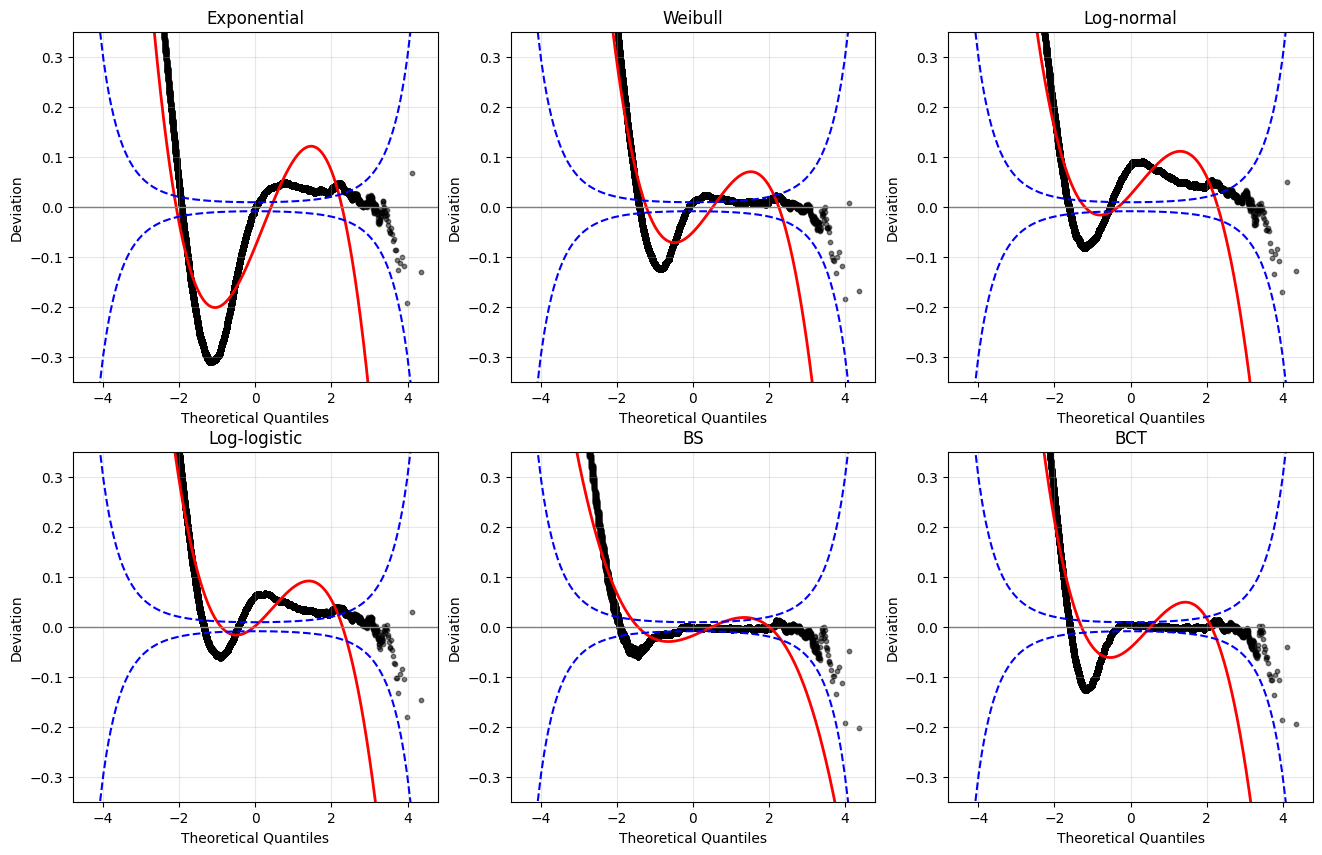

In [42]:
fig, ax = plt.subplots(nrows = 2, ncols = 3, figsize = (16,10))

plot_worm( simple_resid_test_exp, ax = ax[0,0] )
plot_worm( simple_resid_test_weibull, ax = ax[0,1] )
plot_worm( simple_resid_test_lognormal, ax = ax[0,2] )
plot_worm( simple_resid_test_loglogistic, ax = ax[1,0] )
plot_worm( simple_resid_test_bs, ax = ax[1,1] )
plot_worm( simple_resid_test_bct, ax = ax[1,2] )

ax[0,0].set_title("Exponential")
ax[0,1].set_title("Weibull")
ax[0,2].set_title("Log-normal")
ax[1,0].set_title("Log-logistic")
ax[1,1].set_title("BS")
ax[1,2].set_title("BCT")

# Rasterize all scatter points and lines
for i, a in enumerate(ax.flatten()):
    for collection in a.collections:
        collection.set_rasterized(True)
    for line in a.lines:
        if line.get_alpha() is not None and line.get_alpha() < 1.0:
            line.set_rasterized(True)

y_min = -0.35
y_max = 0.35
ax[0,0].set_ylim(y_min,y_max)
ax[0,1].set_ylim(y_min,y_max)
ax[0,2].set_ylim(y_min,y_max)
ax[1,0].set_ylim(y_min,y_max)
ax[1,1].set_ylim(y_min,y_max)
ax[1,2].set_ylim(y_min,y_max)

plt.savefig('../Images/wormplot_without_covariates.png', format='png', dpi=300, bbox_inches='tight')
plt.savefig('../Images/wormplot_without_covariates.pdf', format='pdf', dpi=300, bbox_inches='tight')

plt.show()

In [37]:
results_exp = ph.get_survival_exp(exp_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100, simple = False)
results_weibull = ph.get_survival_weibull(weibull_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100, simple = False)
results_lognormal = ph.get_survival_lognormal(lognormal_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100, simple = False)
results_loglogistic = ph.get_survival_loglogistic(loglogistic_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100, simple = False)
results_bs = ph.get_survival_bs(bs_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100, simple = False)
results_bct = ph.get_survival_bct(bct_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100, simple = False)

In [38]:
resid_train_exp = compute_randomized_residuals_censoring(results_exp["S_train"], delta_train)
resid_test_exp = compute_randomized_residuals_censoring(results_exp["S_test"], delta_test)
resid_train_weibull = compute_randomized_residuals_censoring(results_weibull["S_train"], delta_train)
resid_test_weibull = compute_randomized_residuals_censoring(results_weibull["S_test"], delta_test)
resid_train_lognormal = compute_randomized_residuals_censoring(results_lognormal["S_train"], delta_train)
resid_test_lognormal = compute_randomized_residuals_censoring(results_lognormal["S_test"], delta_test)
resid_train_loglogistic = compute_randomized_residuals_censoring(results_loglogistic["S_train"], delta_train)
resid_test_loglogistic = compute_randomized_residuals_censoring(results_loglogistic["S_test"], delta_test)
resid_train_bs = compute_randomized_residuals_censoring(results_bs["S_train"], delta_train)
resid_test_bs = compute_randomized_residuals_censoring(results_bs["S_test"], delta_test)
resid_train_bct = compute_randomized_residuals_censoring(results_bct["S_train"], delta_train)
resid_test_bct = compute_randomized_residuals_censoring(results_bct["S_test"], delta_test)

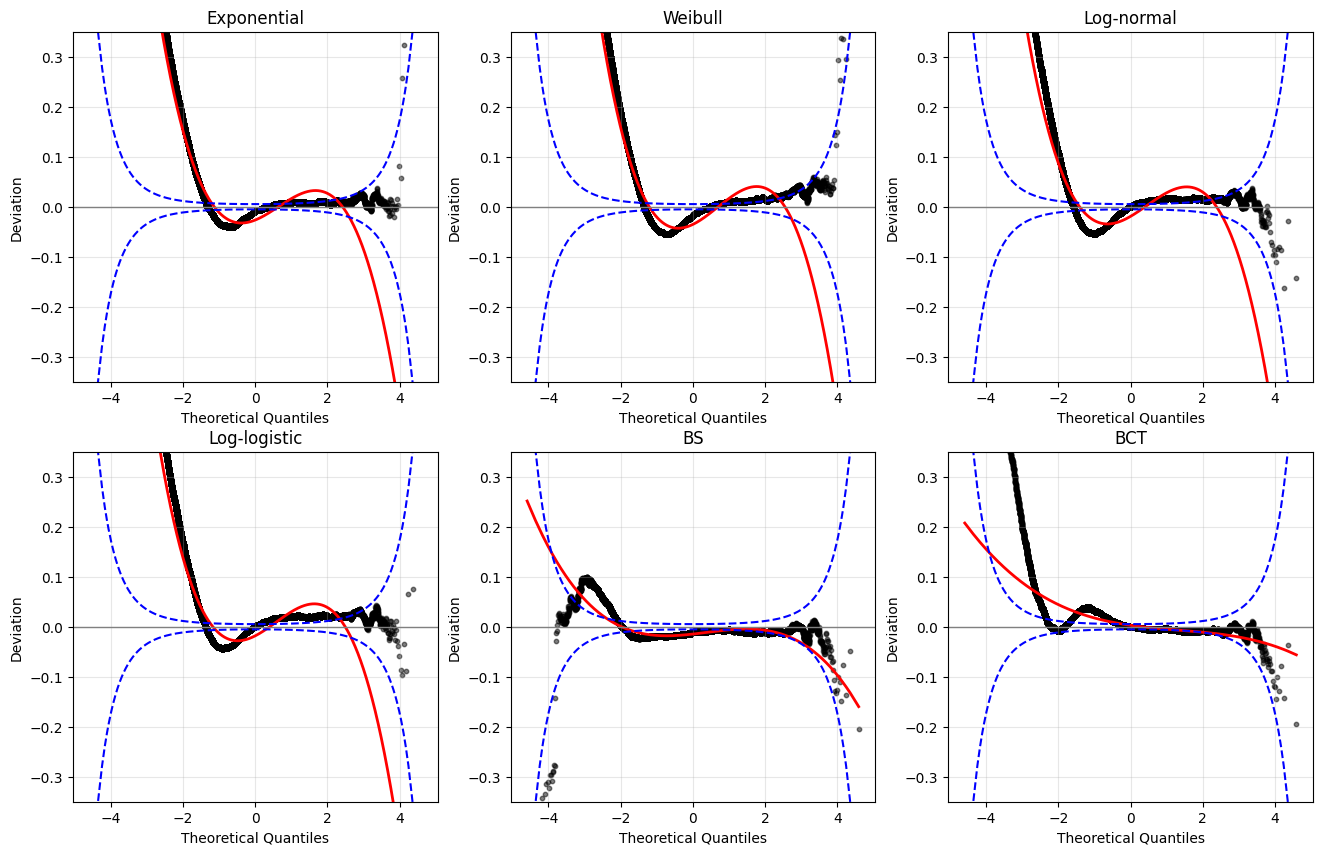

In [43]:
fig, ax = plt.subplots(nrows = 2, ncols = 3, figsize = (16,10))

plot_worm( resid_train_exp, ax = ax[0,0] )
plot_worm( resid_train_weibull, ax = ax[0,1] )
plot_worm( resid_train_lognormal, ax = ax[0,2] )
plot_worm( resid_train_loglogistic, ax = ax[1,0] )
plot_worm( resid_train_bs, ax = ax[1,1] )
plot_worm( resid_train_bct, ax = ax[1,2] )

ax[0,0].set_title("Exponential")
ax[0,1].set_title("Weibull")
ax[0,2].set_title("Log-normal")
ax[1,0].set_title("Log-logistic")
ax[1,1].set_title("BS")
ax[1,2].set_title("BCT")

# Rasterize all scatter points and lines
for i, a in enumerate(ax.flatten()):
    for collection in a.collections:
        collection.set_rasterized(True)
    for line in a.lines:
        if line.get_alpha() is not None and line.get_alpha() < 1.0:
            line.set_rasterized(True)

y_min = -0.35
y_max = 0.35
ax[0,0].set_ylim(y_min,y_max)
ax[0,1].set_ylim(y_min,y_max)
ax[0,2].set_ylim(y_min,y_max)
ax[1,0].set_ylim(y_min,y_max)
ax[1,1].set_ylim(y_min,y_max)
ax[1,2].set_ylim(y_min,y_max)

plt.savefig('../Images/wormplot_with_covariates.png', format='png', dpi=300, bbox_inches='tight')
plt.savefig('../Images/wormplot_with_covariates.pdf', format='pdf', dpi=300, bbox_inches='tight')

plt.show()

As we can see, the clear winner for the closest residual distribution to the standard normal is the BS model. Below, we present the AD test statistics for all models, for which the BS dominates far from its alternatives. That indicates that, although the BS is slightly biased to underestimate the expected, marginal, survival curve, it is the best conditional model with respect to the covariates, describing almost perfectly the intrinsic distribution of each patient in their respective observed lifetimes.

That suggests the BS model is the most reliable fit both to interpret the $\boldsymbol \beta$ coefficients, reaching definitive conclusions over the variables effects and to predict individual worker curves for demission. This guarantees a personalized prediction set for all observations.

In [37]:
from scipy.stats import anderson, kstest

# Anderson-Darling Tests
train_anderson_exp = anderson(resid_train_exp, "norm").statistic
test_anderson_exp = anderson(resid_test_exp, "norm").statistic
train_anderson_weibull = anderson(resid_train_weibull, "norm").statistic
test_anderson_weibull = anderson(resid_test_weibull, "norm").statistic
train_anderson_lognormal = anderson(resid_train_lognormal, "norm").statistic
test_anderson_lognormal = anderson(resid_test_lognormal, "norm").statistic
train_anderson_loglogistic = anderson(resid_train_loglogistic, "norm").statistic
test_anderson_loglogistic = anderson(resid_test_loglogistic, "norm").statistic
train_anderson_bs = anderson(resid_train_bs, "norm").statistic
test_anderson_bs = anderson(resid_test_bs, "norm").statistic
train_anderson_bct = anderson(resid_train_bct, "norm").statistic
test_anderson_bct = anderson(resid_test_bct, "norm").statistic

anderson_values = pd.DataFrame({
    "Model": ["Exponential", "Exponential", "Weibull", "Weibull", "Lognormal", "Lognormal", "Loglogistic", "Loglogistic", "BS", "BS", "BCT", "BCT"],
    "Set": ["Train", "Test", "Train", "Test", "Train", "Test", "Train", "Test", "Train", "Test", "Train", "Test"],
    "AD": [train_anderson_exp, test_anderson_exp, train_anderson_weibull, test_anderson_weibull,
           train_anderson_lognormal, test_anderson_lognormal, train_anderson_loglogistic, test_anderson_loglogistic,
           train_anderson_bs, test_anderson_bs, train_anderson_bct, test_anderson_bct]
})
anderson_values.sort_values(by = ["Set", "AD"])

,Model,Set,AD
9,BS,Test,0.424144
11,BCT,Test,5.081880
5,Lognormal,Test,22.558805
7,Loglogistic,Test,31.103504
1,Exponential,Test,40.200869
3,Weibull,Test,47.188242
8,BS,Train,3.028394
10,BCT,Train,6.058064
4,Lognormal,Train,79.654173
0,Exponential,Train,124.361420


In [38]:
print(np.round(anderson_values.sort_values(by = ["Set", "AD"]), 2).loc[:,["Set", "Model", "AD"]].to_latex(
    index=False,
    float_format="%.2f",
    column_format="lcc",
    caption="Model Performance Summary",
    label="tab:model_perf"
))

\begin{table}
\caption{Model Performance Summary}
\label{tab:model_perf}
\begin{tabular}{lcc}
\toprule
Set & Model & AD \\
\midrule
Test & BS & 0.42 \\
Test & BCT & 5.08 \\
Test & Lognormal & 22.56 \\
Test & Loglogistic & 31.10 \\
Test & Exponential & 40.20 \\
Test & Weibull & 47.19 \\
Train & BS & 3.03 \\
Train & BCT & 6.06 \\
Train & Lognormal & 79.65 \\
Train & Exponential & 124.36 \\
Train & Loglogistic & 125.38 \\
Train & Weibull & 167.68 \\
\bottomrule
\end{tabular}
\end{table}



## Analysis of $\boldsymbol \beta$ coefficients

Given we selected the BS as the winning model in this context, we are ready to interpret the results for the chosen linear variables.

In [39]:
pd.set_option('display.float_format', '{:.6f}'.format)
bs_beta_summary = ph.summary_betas( bs_model, z_train.columns )
betas_covariance_matrix = pd.DataFrame( bs_model.weights_covariance[:14,:14].numpy() )
betas_covariance_matrix.index = z_train.columns
betas_covariance_matrix.columns = z_train.columns
display( bs_beta_summary )
pd.reset_option('display.float_format')

/home/garibay/.pyenv/versions/3.10.13/lib/python3.10/site-packages/thetaflow/modelnn.py:2864: UserWarning: Model supports both neural network modeled parameters and independent parameters.
As a list of input values, x, was not provided, obtaining the covariances only for ['beta'].
  warnings.warn(


,Coef,Se,Z,pvalue,CI(95%)
idade,-0.456976,0.005552,-82.309322,0.000000,(-0.4679 ; -0.4461)
sexo_feminino,0.197364,0.012399,15.917958,0.000000,(0.1731 ; 0.2217)
raca_amarela,0.322815,0.062132,5.195616,0.000000,(0.201 ; 0.4446)
raca_indigena,0.296710,0.120489,2.462540,0.013796,(0.0606 ; 0.5329)
raca_parda,0.238281,0.009436,25.253300,0.000000,(0.2198 ; 0.2568)
raca_preta,0.271380,0.021741,12.482557,0.000000,(0.2288 ; 0.314)
sexo_feminino_raca_amarela,-0.269827,0.091315,-2.954905,0.003128,(-0.4488 ; -0.0909)
sexo_feminino_raca_indigena,-0.241043,0.192054,-1.255079,0.209450,(-0.6175 ; 0.1354)
sexo_feminino_raca_parda,-0.280138,0.018070,-15.502986,0.000000,(-0.3156 ; -0.2447)
sexo_feminino_raca_preta,-0.231785,0.035137,-6.596555,0.000000,(-0.3007 ; -0.1629)


Particularly, the age was standardized to ensure numerical stability, as we train both linear coefficients and neural networks jointly. For interpretation purposes, it is more interesting to retransform its coefficient to its original scale. The sample mean and standard deviation for ages used to scale this data were, respectively, 37.645240783691406 and 11.409568786621094.

In [40]:
pd.set_option('display.float_format', '{:.6f}'.format)
bs_beta_summary_original_scale = ph.summary_betas( bs_model, z_train.columns )

idade_mu = 37.645240783691406
idade_std = 11.409568786621094
bs_beta_summary_original_scale.iloc[0,0] = bs_beta_summary_original_scale.iloc[0,0] / idade_std
bs_beta_summary_original_scale.iloc[0,1] = bs_beta_summary_original_scale.iloc[0,1] / idade_std
bs_beta_lower_original_scale = float( bs_beta_summary_original_scale.iloc[0,4].split(" ; ")[0].replace("(", "") ) / idade_std
bs_beta_upper_original_scale = float( bs_beta_summary_original_scale.iloc[0,4].split(" ; ")[1].replace(")", "") ) / idade_std
bs_beta_ci_original_scale = "({:.4f} ; {:.4f})".format(bs_beta_lower_original_scale, bs_beta_upper_original_scale)
bs_beta_summary_original_scale.iloc[0,4] = bs_beta_ci_original_scale

display( bs_beta_summary_original_scale )
pd.reset_option('display.float_format')

/home/garibay/.pyenv/versions/3.10.13/lib/python3.10/site-packages/thetaflow/modelnn.py:2864: UserWarning: Model supports both neural network modeled parameters and independent parameters.
As a list of input values, x, was not provided, obtaining the covariances only for ['beta'].
  warnings.warn(


,Coef,Se,Z,pvalue,CI(95%)
idade,-0.040052,0.000487,-82.309322,0.000000,(-0.0410 ; -0.0391)
sexo_feminino,0.197364,0.012399,15.917958,0.000000,(0.1731 ; 0.2217)
raca_amarela,0.322815,0.062132,5.195616,0.000000,(0.201 ; 0.4446)
raca_indigena,0.296710,0.120489,2.462540,0.013796,(0.0606 ; 0.5329)
raca_parda,0.238281,0.009436,25.253300,0.000000,(0.2198 ; 0.2568)
raca_preta,0.271380,0.021741,12.482557,0.000000,(0.2288 ; 0.314)
sexo_feminino_raca_amarela,-0.269827,0.091315,-2.954905,0.003128,(-0.4488 ; -0.0909)
sexo_feminino_raca_indigena,-0.241043,0.192054,-1.255079,0.209450,(-0.6175 ; 0.1354)
sexo_feminino_raca_parda,-0.280138,0.018070,-15.502986,0.000000,(-0.3156 ; -0.2447)
sexo_feminino_raca_preta,-0.231785,0.035137,-6.596555,0.000000,(-0.3007 ; -0.1629)


In [41]:
print( bs_beta_summary_original_scale.to_latex(
    index=True,
    float_format="%.4f",
    column_format="lcc",
    caption="Model Performance Summary",
    label="tab:model_perf"
) )

\begin{table}
\caption{Model Performance Summary}
\label{tab:model_perf}
\begin{tabular}{lcc}
\toprule
 & Coef & Se & Z & pvalue & CI(95%) \\
\midrule
idade & -0.0401 & 0.0005 & -82.3093 & 0.0000 & (-0.0410 ; -0.0391) \\
sexo_feminino & 0.1974 & 0.0124 & 15.9180 & 0.0000 & (0.1731 ; 0.2217) \\
raca_amarela & 0.3228 & 0.0621 & 5.1956 & 0.0000 & (0.201 ; 0.4446) \\
raca_indigena & 0.2967 & 0.1205 & 2.4625 & 0.0138 & (0.0606 ; 0.5329) \\
raca_parda & 0.2383 & 0.0094 & 25.2533 & 0.0000 & (0.2198 ; 0.2568) \\
raca_preta & 0.2714 & 0.0217 & 12.4826 & 0.0000 & (0.2288 ; 0.314) \\
sexo_feminino_raca_amarela & -0.2698 & 0.0913 & -2.9549 & 0.0031 & (-0.4488 ; -0.0909) \\
sexo_feminino_raca_indigena & -0.2410 & 0.1921 & -1.2551 & 0.2095 & (-0.6175 ; 0.1354) \\
sexo_feminino_raca_parda & -0.2801 & 0.0181 & -15.5030 & 0.0000 & (-0.3156 ; -0.2447) \\
sexo_feminino_raca_preta & -0.2318 & 0.0351 & -6.5966 & 0.0000 & (-0.3007 ; -0.1629) \\
faixa_remuneracao_media_2 a 4 SM & -0.4582 & 0.0149 & -30.8537 

The summary above considers the following profile for the baseline worker:
* Male;
* White;
* Income of 1 to 2 minimum salaries.
  
From the above summary for the coefficients associated to each variable, we can see that almost all variables are statistically significant to the data.



As it is commonly reported in previous studies, young people tend to be much more susceptible to demissions without cause, with a risk of demission decrease of approximately $36.68\%$ for each full year increase in age. Although that directly suggests that younger people tend to present higher risks of demissions without cause, the age may be highly correlated to a worker time inside a company, which is a natural result to be expected: their demission risks tend to decrease, the longer they are in that company.

In [42]:
print("Risk decrease each year of experience:", np.round(1-np.exp(-0.456976), 4))

Risk decrease each year of experience: 0.3668


Finally, the results also suggest that higher employee incomes are directly associated to lower risks of them being fired without cause. That may be intimately related to the increase in taxes a company must pay when firing an employee without cause, based on their salaries, such as unemployment insurance and the employee's Government Severance Indemnity Fund (in portuguese, FGTS). We report significant risk decrease of approximately $36.76\%$, $49.18\%$ and $60.78\%$ of demission for employees whose income varies from 2 to 4 MS, 4 to 7 MS and more than 7 MS, respectively. That is, an employee that receives more than 7 MS is $60.78\%$ less likely to being fired than an employee with a standard 1 to 2 MS.

Analogously, for workers with an income lower than a minimum salary, mostly represented by junior apprentice (jovem aprendiz), their risk of getting fired is approximately 2.5 times higher than a regular employee receiving between from 1 to 2 MS.

In [43]:
print("Risk increase up to 1 minimum salaries:", np.round(np.exp(0.925431), 4))
print("Risk decrease 2 to 4 minimum salaries:", np.round(1-np.exp(-0.458192), 4))
print("Risk decrease 4 to 7 minimum salaries:", np.round(1-np.exp(-0.676867), 4))
print("Risk decrease more than 7 minimum salaries:", np.round(1-np.exp(-0.935868), 4))

Risk increase up to 1 minimum salaries: 2.523
Risk decrease 2 to 4 minimum salaries: 0.3676
Risk decrease 4 to 7 minimum salaries: 0.4918
Risk decrease more than 7 minimum salaries: 0.6078


## Sex/Race Profiles

In [44]:
display( bs_beta_summary_original_scale )
pd.reset_option('display.float_format')

,Coef,Se,Z,pvalue,CI(95%)
idade,-0.040052,0.000487,-82.309322,0.000000e+00,(-0.0410 ; -0.0391)
sexo_feminino,0.197364,0.012399,15.917958,0.000000e+00,(0.1731 ; 0.2217)
raca_amarela,0.322815,0.062132,5.195616,2.040430e-07,(0.201 ; 0.4446)
raca_indigena,0.296710,0.120489,2.462540,1.379566e-02,(0.0606 ; 0.5329)
raca_parda,0.238281,0.009436,25.253300,0.000000e+00,(0.2198 ; 0.2568)
raca_preta,0.271380,0.021741,12.482557,0.000000e+00,(0.2288 ; 0.314)
sexo_feminino_raca_amarela,-0.269827,0.091315,-2.954905,3.127657e-03,(-0.4488 ; -0.0909)
sexo_feminino_raca_indigena,-0.241043,0.192054,-1.255079,2.094501e-01,(-0.6175 ; 0.1354)
sexo_feminino_raca_parda,-0.280138,0.018070,-15.502986,0.000000e+00,(-0.3156 ; -0.2447)
sexo_feminino_raca_preta,-0.231785,0.035137,-6.596555,4.208212e-11,(-0.3007 ; -0.1629)


In order to include the study of particular subgroups, it is necessary to obtain the standard errors associated to the final sum of coefficients. For example, by setting an asian female worker, we must consider the sum of the $\beta$ coefficients associated to "sex female", "race asian" and "sex female - race asian". That particular sum has a particular standard error, that can be assessed from the complete covariance matrix for all beta coefficients.

In [45]:
betas_covariance_matrix

,idade,sexo_feminino,raca_amarela,raca_indigena,raca_parda,raca_preta,sexo_feminino_raca_amarela,sexo_feminino_raca_indigena,sexo_feminino_raca_parda,sexo_feminino_raca_preta,faixa_remuneracao_media_2 a 4 SM,faixa_remuneracao_media_4 a 7 SM,faixa_remuneracao_media_até 1 SM,faixa_remuneracao_media_mais de 7 SM
idade,3.082392e-05,9.405096e-07,0.000003,0.000006,0.000002,0.000003,-0.000001,-0.000010,-0.000001,6.304136e-08,-0.000005,-0.000008,0.000006,-0.000014
sexo_feminino,9.405953e-07,1.537316e-04,0.000014,0.000019,0.000014,0.000013,-0.000146,-0.000157,-0.000148,-1.464356e-04,-0.000057,-0.000066,-0.000041,-0.000065
raca_amarela,2.883583e-06,1.414345e-05,0.003860,0.000017,0.000012,0.000011,-0.003857,-0.000022,-0.000011,-1.044817e-05,-0.000053,-0.000061,-0.000039,-0.000093
raca_indigena,5.857976e-06,1.861217e-05,0.000017,0.014518,0.000018,0.000018,-0.000014,-0.014520,-0.000015,-1.416458e-05,-0.000052,-0.000049,-0.000045,-0.000049
raca_parda,1.824461e-06,1.361648e-05,0.000012,0.000018,0.000089,0.000012,-0.000009,-0.000019,-0.000086,-8.660747e-06,-0.000049,-0.000042,-0.000043,-0.000036
raca_preta,2.907634e-06,1.264715e-05,0.000011,0.000018,0.000012,0.000473,-0.000008,-0.000019,-0.000009,-4.694175e-04,-0.000052,-0.000044,-0.000039,-0.000034
sexo_feminino_raca_amarela,-1.026416e-06,-1.461478e-04,-0.003857,-0.000014,-0.000009,-0.000008,0.008338,0.000154,0.000145,1.440050e-04,0.000060,0.000066,0.000033,0.000077
sexo_feminino_raca_indigena,-1.048440e-05,-1.570895e-04,-0.000022,-0.014520,-0.000019,-0.000019,0.000154,0.036885,0.000155,1.537684e-04,0.000066,0.000087,0.000046,0.000092
sexo_feminino_raca_parda,-1.022077e-06,-1.477283e-04,-0.000011,-0.000015,-0.000086,-0.000009,0.000145,0.000155,0.000327,1.451140e-04,0.000061,0.000069,0.000030,0.000070
sexo_feminino_raca_preta,6.289763e-08,-1.464362e-04,-0.000010,-0.000014,-0.000009,-0.000469,0.000144,0.000154,0.000145,1.234625e-03,0.000062,0.000067,0.000032,0.000069


In [46]:
def print_risk(category, coefficient, coefficient_lower, coefficient_upper):
    change_sign = "+" if(coefficient > 0) else "-"
    percentage = (np.exp(coefficient)-1)*100 if(coefficient > 0) else (1-np.exp(coefficient))*100
    
    change_sign_lower = "+" if(coefficient_lower > 0) else "-"
    percentage_lower = (np.exp(coefficient_lower)-1)*100 if(coefficient_lower > 0) else (1-np.exp(coefficient_lower))*100
    
    change_sign_upper = "+" if(coefficient_upper > 0) else "-"
    percentage_upper = (np.exp(coefficient_upper)-1)*100 if(coefficient_upper > 0) else (1-np.exp(coefficient_upper))*100
    print("{}: {:.4f} ({}{:.2f}\%) - [{}{:.2f}\% ; {}{:.2f}\%]".format( category, coefficient,
                                                                              change_sign, percentage,
                                                                              change_sign_lower, percentage_lower,
                                                                              change_sign_upper, percentage_upper ))
alpha = 0.05
z_norm = norm.ppf(1-alpha/2)

# ------------------------------------- White -------------------------------------
white_female = bs_beta_summary_original_scale["Coef"]["sexo_feminino"]
white_female_se = bs_beta_summary_original_scale["Se"]["sexo_feminino"]
white_female_lower = white_female - z_norm * white_female_se
white_female_upper = white_female + z_norm * white_female_se

# ------------------------------------- Asian -------------------------------------
asian_male = bs_beta_summary_original_scale["Coef"]["raca_amarela"]
asian_male_se = bs_beta_summary_original_scale["Se"]["raca_amarela"]
asian_male_lower = asian_male - z_norm * asian_male_se
asian_male_upper = asian_male + z_norm * asian_male_se

c_asian_female = np.array([[0,1,1,0,0,0,1,0,0,0,0,0,0,0]]).T
asian_female = bs_beta_summary_original_scale["Coef"]["sexo_feminino"] + \
               bs_beta_summary_original_scale["Coef"]["raca_amarela"] + \
               bs_beta_summary_original_scale["Coef"]["sexo_feminino_raca_amarela"]
asian_female_se = np.sqrt( (c_asian_female.T @ betas_covariance_matrix @ c_asian_female).iloc[0,0] )
asian_female_lower = asian_female - z_norm * asian_female_se
asian_female_upper = asian_female + z_norm * asian_female_se

# ------------------------------------- Indigenous -------------------------------------
indigenous_male = bs_beta_summary_original_scale["Coef"]["raca_indigena"]
indigenous_male_se = bs_beta_summary_original_scale["Se"]["raca_indigena"]
indigenous_male_lower = indigenous_male - z_norm * indigenous_male_se
indigenous_male_upper = indigenous_male + z_norm * indigenous_male_se

c_indigenous_female = np.array([[0,1,0,1,0,0,0,1,0,0,0,0,0,0]]).T
indigenous_female = bs_beta_summary_original_scale["Coef"]["sexo_feminino"] + \
                    bs_beta_summary_original_scale["Coef"]["raca_indigena"] + \
                    bs_beta_summary_original_scale["Coef"]["sexo_feminino_raca_indigena"]
indigenous_female_se = np.sqrt( (c_indigenous_female.T @ betas_covariance_matrix @ c_indigenous_female).iloc[0,0] )
indigenous_female_lower = indigenous_female - z_norm * indigenous_female_se
indigenous_female_upper = indigenous_female + z_norm * indigenous_female_se

# ------------------------------------- Brown -------------------------------------
brown_male = bs_beta_summary_original_scale["Coef"]["raca_parda"]
brown_male_se = bs_beta_summary_original_scale["Se"]["raca_parda"]
brown_male_lower = brown_male - z_norm * brown_male_se
brown_male_upper = brown_male + z_norm * brown_male_se

c_brown_female = np.array([[0,1,0,0,1,0,0,0,1,0,0,0,0,0]]).T
brown_female = bs_beta_summary_original_scale["Coef"]["sexo_feminino"] + \
               bs_beta_summary_original_scale["Coef"]["raca_parda"] + \
               bs_beta_summary_original_scale["Coef"]["sexo_feminino_raca_parda"]
brown_female_se = np.sqrt( (c_brown_female.T @ betas_covariance_matrix @ c_brown_female).iloc[0,0] )
brown_female_lower = brown_female - z_norm * brown_female_se
brown_female_upper = brown_female + z_norm * brown_female_se

# ------------------------------------- Black -------------------------------------
black_male = bs_beta_summary_original_scale["Coef"]["raca_preta"]
black_male_se = bs_beta_summary_original_scale["Se"]["raca_preta"]
black_male_lower = black_male - z_norm * black_male_se
black_male_upper = black_male + z_norm * black_male_se

c_black_female = np.array([[0,1,0,0,0,1,0,0,0,1,0,0,0,0]]).T
black_female = bs_beta_summary_original_scale["Coef"]["sexo_feminino"] + \
               bs_beta_summary_original_scale["Coef"]["raca_preta"] + \
               bs_beta_summary_original_scale["Coef"]["sexo_feminino_raca_preta"]
black_female_se = np.sqrt( (c_black_female.T @ betas_covariance_matrix @ c_black_female).iloc[0,0] )
black_female_lower = black_female - z_norm * black_female_se
black_female_upper = black_female + z_norm * black_female_se

print_risk("White female", white_female, white_female_lower, white_female_upper)
print("------------------------------------")
print_risk("Asian male", asian_male, asian_male_lower, asian_male_upper)
print_risk("Asian female", asian_female, asian_female_lower, asian_female_upper)
print("------------------------------------")
print_risk("Indigenous male", indigenous_male, indigenous_male_lower, indigenous_male_upper)
print_risk("Indigenous female", indigenous_female, indigenous_female_lower, indigenous_female_upper)
print("------------------------------------")
print_risk("Brown male", brown_male, brown_male_lower, brown_male_upper)
print_risk("Brown female", brown_female, brown_female_lower, brown_female_upper)
print("------------------------------------")
print_risk("Black male", black_male, black_male_lower, black_male_upper)
print_risk("Black female", black_female, black_female_lower, black_female_upper)

White female: 0.1974 (+21.82\%) - [+18.89\% ; +24.82\%]
------------------------------------
Asian male: 0.3228 (+38.10\%) - [+22.27\% ; +55.99\%]
Asian female: 0.2504 (+28.45\%) - [+12.83\% ; +46.23\%]
------------------------------------
Indigenous male: 0.2967 (+34.54\%) - [+6.24\% ; +70.38\%]
Indigenous female: 0.2530 (+28.79\%) - [-3.85\% ; +72.52\%]
------------------------------------
Brown male: 0.2383 (+26.91\%) - [+24.58\% ; +29.28\%]
Brown female: 0.1555 (+16.83\%) - [+14.24\% ; +19.46\%]
------------------------------------
Black male: 0.2714 (+31.18\%) - [+25.71\% ; +36.89\%]
Black female: 0.2370 (+26.74\%) - [+20.54\% ; +33.26\%]


In [47]:
asian_prop = np.mean(df_train["raca_amarela"])
indigenous_prop = np.mean(df_train["raca_indigena"])
brown_prop = np.mean(df_train["raca_parda"])
black_prop = np.mean(df_train["raca_preta"])
white_prop = 1 - asian_prop - indigenous_prop - brown_prop - black_prop

print("Races distribution:")
print("White: {:.2f}%".format( white_prop*100 ))
print("Asian: {:.2f}%".format( asian_prop*100 ))
print("Indigenous: {:.2f}%".format( indigenous_prop*100 ))
print("Brown: {:.2f}%".format( brown_prop*100 ))
print("Black: {:.2f}%".format( black_prop*100 ))

Races distribution:
White: 38.39%
Asian: 1.15%
Indigenous: 0.25%
Brown: 51.53%
Black: 8.68%


## Sex difference inside races

Now, we investigate the actual differences between both sexes inside each race profile. Our goal is to determine whether there is a significant difference between men and women inside each class with respect to the dismissal risk.

As an example, a black man has the incoming effects of $\beta_\text{Black}$, while a black woman has $\beta_\text{Black} + \beta_\text{Female} + \beta_\text{Black Female}$, so we are interested in the difference between both, which is given by $\beta_\text{Female} + \beta_\text{Black Female}$, that is, the statistical significance of that coefficient, which is best translated in the risk increase from one class to the other.

In [48]:
alpha = 0.05
z_norm = norm.ppf(1-alpha/2)

# ------------------------------------- White -------------------------------------
white_female = bs_beta_summary_original_scale["Coef"]["sexo_feminino"]
white_female_se = bs_beta_summary_original_scale["Se"]["sexo_feminino"]
white_female_lower = white_female - z_norm * white_female_se
white_female_upper = white_female + z_norm * white_female_se

# ------------------------------------- Asian -------------------------------------
c_asian_female = np.array([[0,1,0,0,0,0,1,0,0,0,0,0,0,0]]).T
asian_female = bs_beta_summary_original_scale["Coef"]["sexo_feminino"] + \
               bs_beta_summary_original_scale["Coef"]["sexo_feminino_raca_amarela"]
asian_female_se = np.sqrt( (c_asian_female.T @ betas_covariance_matrix @ c_asian_female).iloc[0,0] )
asian_female_lower = asian_female - z_norm * asian_female_se
asian_female_upper = asian_female + z_norm * asian_female_se

# ------------------------------------- Indigenous -------------------------------------
c_indigenous_female = np.array([[0,1,0,0,0,0,0,1,0,0,0,0,0,0]]).T
indigenous_female = bs_beta_summary_original_scale["Coef"]["sexo_feminino"] + \
                    bs_beta_summary_original_scale["Coef"]["sexo_feminino_raca_indigena"]
indigenous_female_se = np.sqrt( (c_indigenous_female.T @ betas_covariance_matrix @ c_indigenous_female).iloc[0,0] )
indigenous_female_lower = indigenous_female - z_norm * indigenous_female_se
indigenous_female_upper = indigenous_female + z_norm * indigenous_female_se

# ------------------------------------- Brown -------------------------------------
c_brown_female = np.array([[0,1,0,0,0,0,0,0,1,0,0,0,0,0]]).T
brown_female = bs_beta_summary_original_scale["Coef"]["sexo_feminino"] + \
               bs_beta_summary_original_scale["Coef"]["sexo_feminino_raca_parda"]
brown_female_se = np.sqrt( (c_brown_female.T @ betas_covariance_matrix @ c_brown_female).iloc[0,0] )
brown_female_lower = brown_female - z_norm * brown_female_se
brown_female_upper = brown_female + z_norm * brown_female_se

# ------------------------------------- Black -------------------------------------
c_black_female = np.array([[0,1,0,0,0,0,0,0,0,1,0,0,0,0]]).T
black_female = bs_beta_summary_original_scale["Coef"]["sexo_feminino"] + \
               bs_beta_summary_original_scale["Coef"]["sexo_feminino_raca_preta"]
black_female_se = np.sqrt( (c_black_female.T @ betas_covariance_matrix @ c_black_female).iloc[0,0] )
black_female_lower = black_female - z_norm * black_female_se
black_female_upper = black_female + z_norm * black_female_se

print_risk("White female", white_female, white_female_lower, white_female_upper)
print("------------------------------------")
print_risk("Asian female", asian_female, asian_female_lower, asian_female_upper)
print("------------------------------------")
print_risk("Indigenous female", indigenous_female, indigenous_female_lower, indigenous_female_upper)
print("------------------------------------")
print_risk("Brown female", brown_female, brown_female_lower, brown_female_upper)
print("------------------------------------")
print_risk("Black female", black_female, black_female_lower, black_female_upper)

White female: 0.1974 (+21.82\%) - [+18.89\% ; +24.82\%]
------------------------------------
Asian female: -0.0725 (-6.99\%) - [-22.12\% ; +11.07\%]
------------------------------------
Indigenous female: -0.0437 (-4.27\%) - [-34.25\% ; +39.36\%]
------------------------------------
Brown female: -0.0828 (-7.94\%) - [-10.36\% ; -5.46\%]
------------------------------------
Black female: -0.0344 (-3.38\%) - [-9.45\% ; +3.09\%]
